# <font color='dark'>**Seleção e agrupamento de dados com pandas**</font>

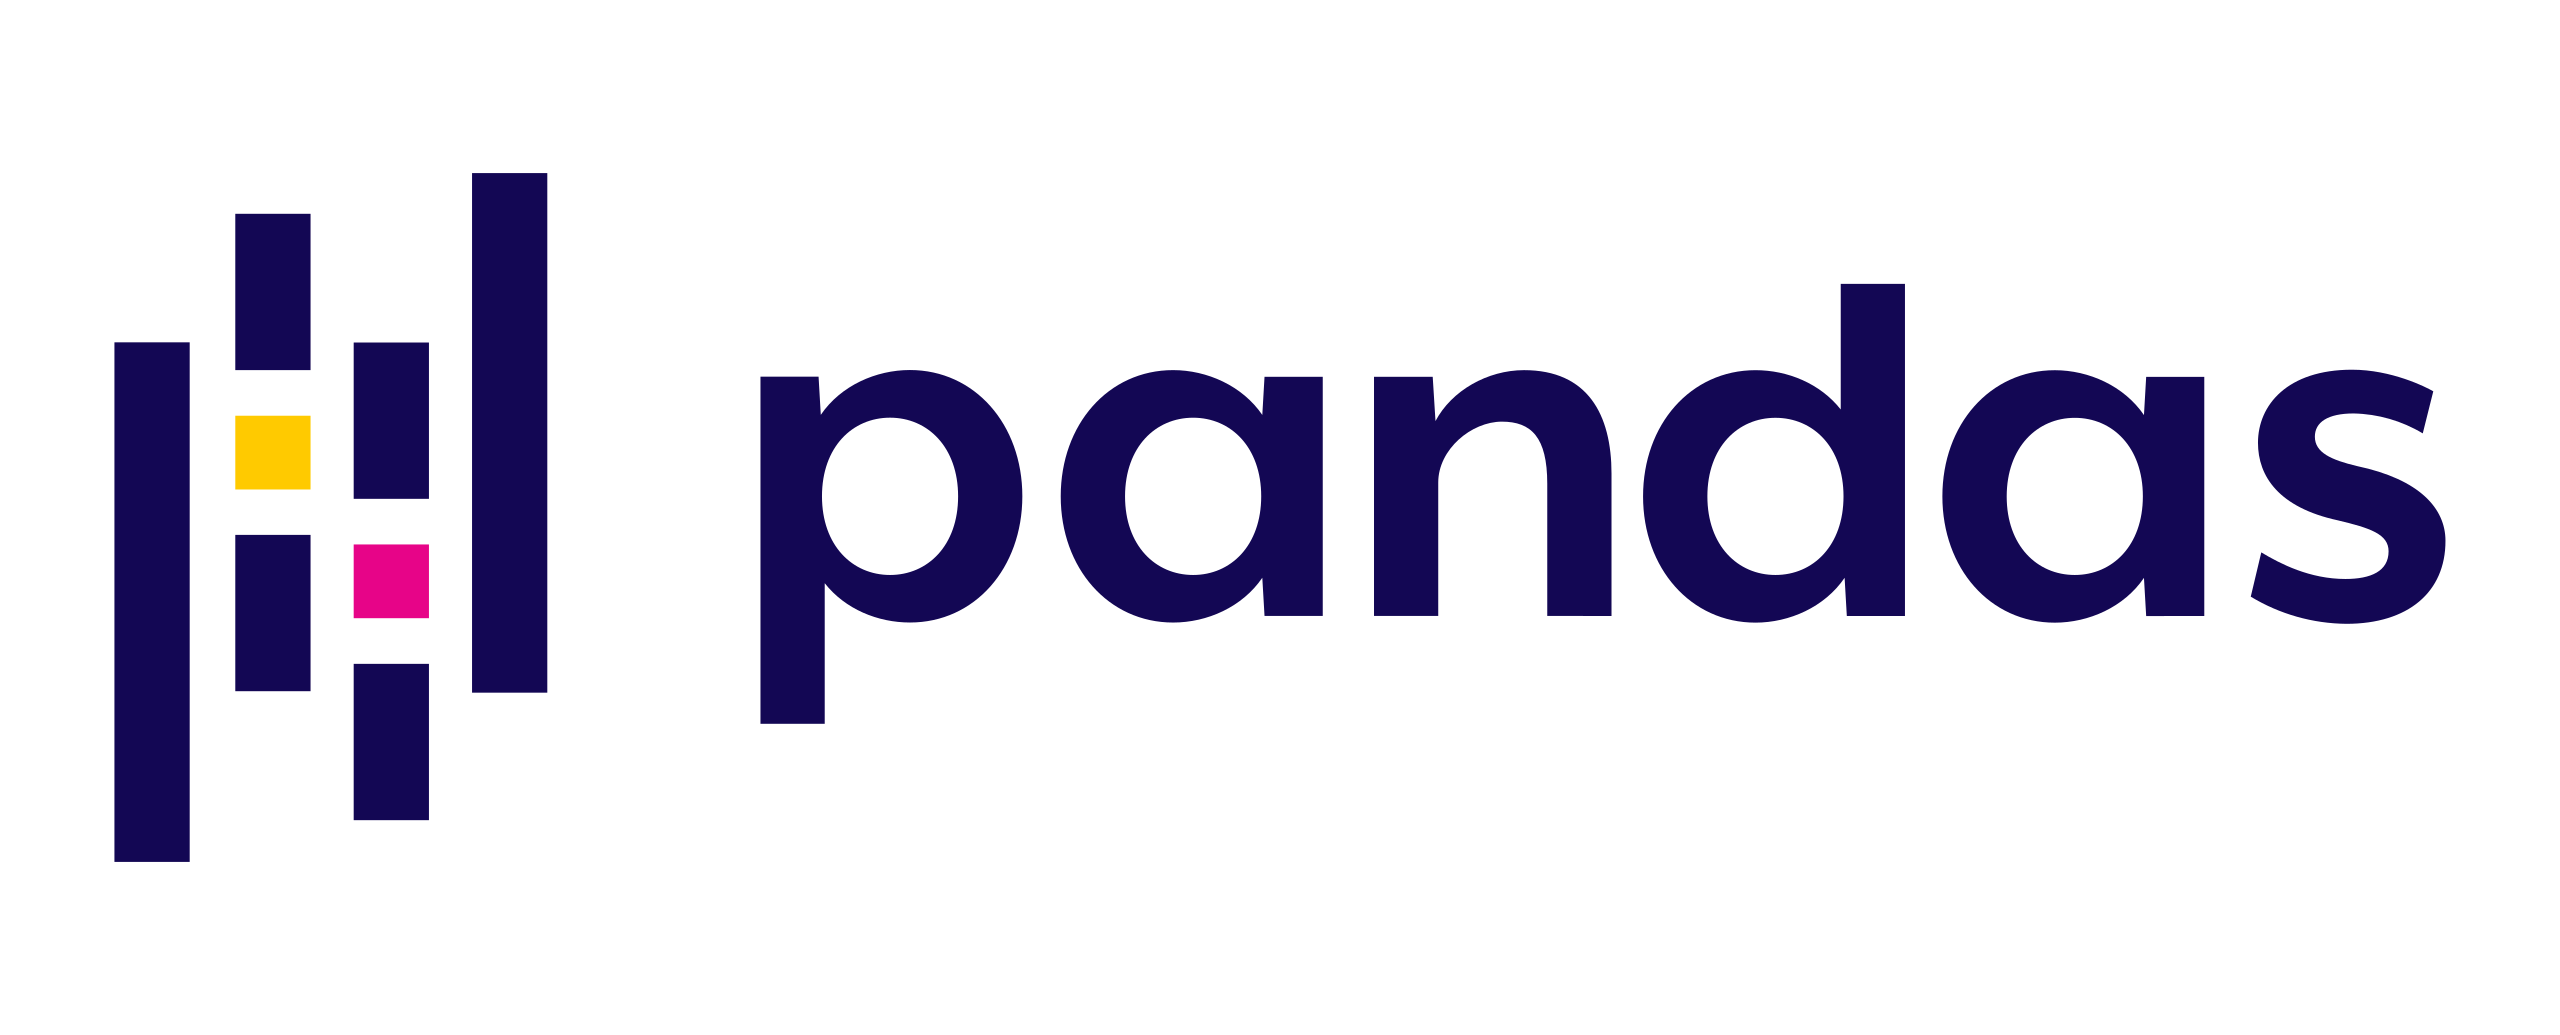

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Fazendo a leitura dos dados

Vamos analisar dados de emissões de gases de efeito estufa no território brasileiro e criar tabelas e visualizações para entender os dados e gerar insights a partir deles. Os dados foram extraídos do SEEG.

---
ℹ Fonte: SEEG - Sistema de Estimativa de Emissões e Remoções de Gases de Efeito Estufa, Observatório do Clima, acessado em http://seeg.eco.br:

- [Download da base de dados](http://seeg.eco.br/download)
---

Primeiramente, vamos importar a biblioteca [`pandas`](https://pandas.pydata.org/docs/index.html) e os dados que serão utilizados. Como os dados estão em um arquivo excel, vamos usar a função [`read_excel()`](https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html).

Vamos checar a estrutura do nosso DataFrame com o uso do método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html?highlight=info#pandas.DataFrame.info), que retorna a quantidade de linhas e colunas, bem como a informação de quantidade de dados nulos e tipos de dados para cada uma das colunas.

### Ajustando a base de dados

Estamos interessados somente na emissão de gases gerados pelos estados que estejam no inventário nacional, portanto vamos identificar os tipos de dados únicos da coluna *Emissão / Remoção / Bunker*.

---
ℹ
- *Remoções são dados referentes à retirada dos gases estufa, que é o contrário da emissão*
- *NCI são dados não contemplados no inventário nacional*
- *Bunkers são emissões de transporte marítimo e aéreo internacional, portanto não são emissões diretas dos estados.*

*Informação disponível no site do SEEG: https://seeg.eco.br/entenda-as-estimativas*

---

In [3]:
import pandas as pd

In [4]:
emissoes_gases = pd.read_excel('/content/drive/MyDrive/Alura/1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx', sheet_name = 'GEE Estados')

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [5]:
emissoes_gases

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,8.976000e+02,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,1.300000e+02,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1.380576e+03,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,4.314300e+02,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,4.030000e+04,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103307,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GTP-AR6,BR,NaN,...,2731963.400,1091033.900,853275.300,1003731.400,1615000.600,1552258.800,216231.900,2805297.300,9.659261e+06,0.000
103308,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR2,BR,NaN,...,2921341.000,1144504.000,896685.000,1074717.000,1763431.000,1706030.000,252599.000,3105007.000,1.053571e+07,0.000
103309,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR4,BR,NaN,...,2950049.000,1151848.000,902209.000,1084073.000,1782863.000,1726958.000,257507.000,3147567.000,1.067568e+07,0.000
103310,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR5,BR,NaN,...,2957780.000,1152868.000,902368.000,1084826.000,1784237.000,1729598.000,258068.000,3155415.000,1.072232e+07,0.000


In [6]:
emissoes_gases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  object 
 1   Nível 2                     103312 non-null  object 
 2   Nível 3                     103253 non-null  object 
 3   Nível 4                     90920 non-null   object 
 4   Nível 5                     100788 non-null  object 
 5   Nível 6                     97691 non-null   object 
 6   Emissão / Remoção / Bunker  103312 non-null  object 
 7   Gás                         103312 non-null  object 
 8   Estado                      97374 non-null   object 
 9   Atividade Econômica         102076 non-null  object 
 10  Produto                     37413 non-null   object 
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  float64
 13  1972          

In [7]:
emissoes_gases['Emissão / Remoção / Bunker'].unique()

array(['Emissão', 'Emissão NCI', 'Remoção NCI', 'Bunker', 'Remoção'],
      dtype=object)

Vamos checar primeiro os dados de remoção, para identificar se todos eles são de retirada de gases estufa.

In [8]:
(emissoes_gases['Emissão / Remoção / Bunker'] == 'Remoção NCI') | (emissoes_gases['Emissão / Remoção / Bunker'] == 'Remoção')

,Emissão / Remoção / Bunker
0,False
1,False
2,False
3,False
4,False
...,...
103307,False
103308,False
103309,False
103310,False


In [9]:
(emissoes_gases['Emissão / Remoção / Bunker'] == 'Remoção NCI') | (emissoes_gases['Emissão / Remoção / Bunker'] == 'Remoção')

,Emissão / Remoção / Bunker
0,False
1,False
2,False
3,False
4,False
...,...
103307,False
103308,False
103309,False
103310,False


In [10]:
emissoes_gases[emissoes_gases['Emissão / Remoção / Bunker'].isin(['Remoção NCI', 'Remoção'])]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
23520,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),RO,PEC,...,-1.434540e+07,-1.499358e+07,-1.543196e+07,-1.567070e+07,-1.630063e+07,-1.702215e+07,-1.740074e+07,-1.771914e+07,-1.767632e+07,-1.838895e+07
23521,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),AC,PEC,...,-5.382949e+06,-5.524659e+06,-5.632429e+06,-5.765030e+06,-5.867354e+06,-5.942076e+06,-6.022000e+06,-6.002147e+06,-6.035591e+06,-6.459079e+06
23522,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),AM,PEC,...,-3.450455e+06,-3.540294e+06,-3.545724e+06,-3.924546e+06,-4.626541e+06,-4.874199e+06,-4.849173e+06,-4.959540e+06,-5.106806e+06,-5.809814e+06
23523,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),RR,PEC,...,-1.260166e+06,-1.261895e+06,-1.371664e+06,-1.501452e+06,-1.507705e+06,-1.509919e+06,-1.609826e+06,-1.616980e+06,-1.518397e+06,-1.926000e+06
23524,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),PA,PEC,...,-3.429279e+07,-3.317185e+07,-3.281628e+07,-3.350720e+07,-3.557183e+07,-3.755308e+07,-4.134614e+07,-4.229403e+07,-4.275448e+07,-4.443440e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102751,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR4,MS,AGROPEC,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102752,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR5,MT,AGROPEC,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04
102753,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR5,MS,AGROPEC,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102754,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR6,MT,AGROPEC,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04


Para identificar se todos os valores são negativos, vamos utilizar a função `max()` para checar se tem algum valor maior do que 0.

In [11]:
emissoes_gases.loc[emissoes_gases['Emissão / Remoção / Bunker'].isin(['Remoção NCI', 'Remoção']),1970:2021]

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
23520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.434540e+07,-1.499358e+07,-1.543196e+07,-1.567070e+07,-1.630063e+07,-1.702215e+07,-1.740074e+07,-1.771914e+07,-1.767632e+07,-1.838895e+07
23521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-5.382949e+06,-5.524659e+06,-5.632429e+06,-5.765030e+06,-5.867354e+06,-5.942076e+06,-6.022000e+06,-6.002147e+06,-6.035591e+06,-6.459079e+06
23522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-3.450455e+06,-3.540294e+06,-3.545724e+06,-3.924546e+06,-4.626541e+06,-4.874199e+06,-4.849173e+06,-4.959540e+06,-5.106806e+06,-5.809814e+06
23523,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.260166e+06,-1.261895e+06,-1.371664e+06,-1.501452e+06,-1.507705e+06,-1.509919e+06,-1.609826e+06,-1.616980e+06,-1.518397e+06,-1.926000e+06
23524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-3.429279e+07,-3.317185e+07,-3.281628e+07,-3.350720e+07,-3.557183e+07,-3.755308e+07,-4.134614e+07,-4.229403e+07,-4.275448e+07,-4.443440e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04
102753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102754,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04


In [12]:
emissoes_gases.loc[emissoes_gases['Emissão / Remoção / Bunker'].isin(['Remoção NCI', 'Remoção']),1970:2021].max()

,0
1970,0.0
1971,0.0
1972,0.0
1973,0.0
1974,0.0
1975,0.0
1976,0.0
1977,0.0
1978,0.0
1979,0.0


Vamos também identificar se algum valor do tipo *Bunker* corresponde a alguma emissão feita por algum estado.

In [13]:
emissoes_gases.loc[emissoes_gases['Emissão / Remoção / Bunker'] == 'Bunker', 'Estado'].unique()

array([nan], dtype=object)

In [14]:
emissoes_gases = emissoes_gases[emissoes_gases['Emissão / Remoção / Bunker'] == 'Emissão']
emissoes_gases

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000,40300.000,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103241,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR5,MS,AGROPEC,...,436935.000000,500067.000000,440030.000000,365272.000000,438422.000000,391113.000000,411738.000000,437039.000,871393.000,1004191.000
103242,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR6,MT,AGROPEC,...,126806.000000,127558.000000,193758.000000,164585.000000,234509.000000,190412.000000,162919.000000,186091.000,368149.000,443120.000
103243,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR6,MS,AGROPEC,...,439524.000000,502908.000000,442493.000000,367116.000000,440798.000000,393101.000000,413749.000000,439526.000,876637.000,1009968.000
103244,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,N2O (t),MT,AGROPEC,...,108.441090,109.811199,166.680103,141.442361,201.556097,162.932751,137.219684,158.000,314.000,479.000


Como não restou nenhum valor útil para análise na coluna de *Emissão / Remoção / Bunker*, vamos removê-la por completo da base de dados.

In [15]:
emissoes_gases = emissoes_gases.drop(columns= 'Emissão / Remoção / Bunker')

In [16]:
emissoes_gases

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,...,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600000,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,...,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576000,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,...,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430000,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,...,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000000,40300.000,40300.000,40300.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103241,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,...,436935.000000,500067.000000,440030.000000,365272.000000,438422.000000,391113.000000,411738.000000,437039.000,871393.000,1004191.000
103242,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,...,126806.000000,127558.000000,193758.000000,164585.000000,234509.000000,190412.000000,162919.000000,186091.000,368149.000,443120.000
103243,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,...,439524.000000,502908.000000,442493.000000,367116.000000,440798.000000,393101.000000,413749.000000,439526.000,876637.000,1009968.000
103244,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,...,108.441090,109.811199,166.680103,141.442361,201.556097,162.932751,137.219684,158.000,314.000,479.000


Desafio

Encontre os valores únicos das colunas "Nível 1 - Setor" e "Estado" para identificar as atividades econômicas presentes na base de dados e se todos os Estados do Brasil estão presentes no DataFrame.

Filtre o DataFrame somente com os dados dos Estados da região Sul do Brasil.

Filtre o DataFrame para exibir apenas os registros em que o campo "Nível 1 - Setor" seja igual a "Mudança de Uso da Terra e Floresta" e o campo "Estado" seja igual a "AM" (sigla para o Estado do Amazonas).

Encontre o valor máximo de emissão do ano de 2021 para os dados de "Agropecuária" no Estado do Pará.

1) Para encontrar valores únicos de uma coluna do DataFrame, podemos utilizar o método unique():

In [17]:
emissoes_gases['Nível 1 - Setor'].unique()

array(['Processos Industriais', 'Agropecuária', 'Energia', 'Resíduos ',
       'Mudança de Uso da Terra e Floresta'], dtype=object)

Para encontrar valores únicos de uma coluna do DataFrame, podemos utilizar o método unique():

In [18]:
emissoes_gases['Estado'].unique()

array(['SP', 'BA', 'RJ', 'MG', 'SE', 'PR', nan, 'RO', 'AM', 'PA', 'TO',
       'MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'MT', 'MS', 'GO', 'DF',
       'ES', 'SC', 'RS', 'AC', 'AP', 'RR'], dtype=object)

2) Para filtrar os Estados da região Sul do Brasil, devemos selecionar os valores da coluna "Estado" que sejam iguais a 'PR' ou 'RS' ou 'SC'. Podemos usar a filtragem booleana em conjunto com o operador OU, usando a barra vertical ( | ). Ou então utilizar o método isin() com os nomes dos Estados em uma lista:

In [19]:
emissoes_gases[emissoes_gases['Estado'].isin(['PR', 'RS', 'SC'])]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
35,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),PR,OUTRA_IND,NaN,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
36,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2e (t) GWP-AR2,PR,OUTRA_IND,NaN,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
37,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2e (t) GTP-AR2,PR,OUTRA_IND,NaN,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
110,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2 (t),PR,CIM,NaN,...,2.012596e+06,2.212002e+06,2.241143e+06,2.176752e+06,2.279061e+06,2.115372e+06,2.173266e+06,2.230656e+06,2.488650e+06,2.845457e+06
111,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,CO2 (t),SC,CIM,NaN,...,7.126368e+05,6.421719e+05,8.163383e+05,6.769844e+05,5.272686e+05,5.143665e+05,5.130451e+05,5.451073e+05,6.144431e+05,7.179804e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103221,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pampa,NaN,Desmatamento,NaN,CO2e (t) GWP-AR2,RS,AGROPEC,NaN,...,1.108518e+06,1.479183e+06,9.718840e+05,9.948190e+05,7.698680e+05,9.057280e+05,9.238730e+05,1.046432e+06,1.439095e+06,1.432812e+06
103222,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pampa,NaN,Desmatamento,NaN,CO2e (t) GWP-AR4,RS,AGROPEC,NaN,...,1.196999e+06,1.599471e+06,1.045298e+06,1.070678e+06,8.308050e+05,9.748940e+05,9.924510e+05,1.124747e+06,1.543126e+06,1.541087e+06
103223,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pampa,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,RS,AGROPEC,NaN,...,1.221927e+06,1.635136e+06,1.062603e+06,1.089187e+06,8.475340e+05,9.918540e+05,1.007627e+06,1.142614e+06,1.563684e+06,1.566694e+06
103224,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pampa,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,RS,AGROPEC,NaN,...,1.232994e+06,1.649637e+06,1.072887e+06,1.099601e+06,8.553060e+05,1.001321e+06,1.017557e+06,1.153771e+06,1.579514e+06,1.581831e+06


3) Podemos fazer uma filtragem booleana usando o operador lógico E, usando o símbolo &:



In [20]:
emissoes_gases[(emissoes_gases['Nível 1 - Setor'] == 'Mudança de Uso da Terra e Floresta') & (emissoes_gases['Estado'] == 'AM')]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
81262,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2 (t),AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
81271,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2e (t) GTP-AR2,AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
81280,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2e (t) GTP-AR4,AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
81289,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2e (t) GTP-AR5,AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
81298,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Amazônia,fora de Área Protegida,Desmatamento,Floresta primária -- Área sem vegetação,CO2e (t) GTP-AR6,AM,AGROPEC,NaN,...,8.511800e+04,9.763700e+04,8.761900e+04,1.218150e+05,1.137590e+05,5.299800e+04,6.117000e+04,48264.0,14381.0,31867.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102803,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Amazônia,NaN,Desmatamento,NaN,CO2e (t) GWP-AR2,AM,AGROPEC,NaN,...,2.239997e+06,3.186571e+06,2.973253e+06,4.796274e+06,7.396711e+06,4.362453e+06,4.434835e+06,7074966.0,8746520.0,8429758.0
102812,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Amazônia,NaN,Desmatamento,NaN,CO2e (t) GWP-AR4,AM,AGROPEC,NaN,...,2.505953e+06,3.565317e+06,3.330733e+06,5.368844e+06,8.276064e+06,4.888099e+06,4.967871e+06,7929733.0,9799770.0,9408067.0
102821,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Amazônia,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,AM,AGROPEC,NaN,...,2.651128e+06,3.772286e+06,3.528292e+06,5.683071e+06,8.756712e+06,5.179207e+06,5.262358e+06,8404321.0,10382705.0,9929881.0
102830,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Amazônia,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,AM,AGROPEC,NaN,...,2.661898e+06,3.787545e+06,3.541992e+06,5.705721e+06,8.792123e+06,5.199159e+06,5.282817e+06,8436366.0,10422789.0,9973416.0


4) Podemos usar o método loc() para fazer a filtragem booleana e selecionar a coluna referente ao ano de 2021 simultaneamente e usar o método max() para extrair o valor máximo de emissão da coluna selecionada:



In [21]:
emissoes_gases.loc[(emissoes_gases['Nível 1 - Setor'] == 'Agropecuária') & (emissoes_gases['Estado'] == 'PA'), 2021].max()

36856969.7986

### Modificando o formato do DataFrame

Para realizar as agregações nos dados de emissão, é necessário que a base de dados esteja em um formato adequado, com os valores de emissão todos em uma mesma coluna. Para isso, devemos modificar o formato da base de dados de forma que as colunas referentes a cada ano se tornem uma só coluna.

Já fizemos a leitura da base de dados e removemos as informações que não serão utilizadas no nosso projeto.

Agora, vamos analisar as emissões por tipo de gases que temos na base de dados, utilizando agrupamento de dados.

Alterando o formato do DataFrame
Para fazer esse agrupamento de forma correta, precisamos alterar o formato do DataFrame. A nossa tabela possui as informações de emissão separada por colunas de anos, mas precisamos alterar o formato para:

Apenas uma coluna contendo as informações dos anos. Assim, cada linha vai conter uma informação de um ano diferente;
Apenas uma coluna com os dados de emissão.
Para isso, vamos precisar manter as informações da coluna "Nível 1 - Setor" até "Produto", ou seja, da primeira a décima coluna. Mas, vamos alterar as informações dos anos de 1970 até 2021.

Isto é, todas as colunas com informações numéricas vão se transformar em apenas duas colunas: uma coluna com informação dos anos (que atualmente está no cabeçalho da coluna) e outra coluna com as informações de emissão.

Armazenando as informações das colunas
Primeiro, vamos armazenar o nome das colunas que vamos manter, ou seja, "Nível 1 - Setor" até "Produto". Também vamos armazenar em variáveis o nome das colunas de 1970 a 2021.

Na primeira célula da seção "Modificando o formato do DataFrame" do Google Colab, vamos escrever emissoes_gases.loc[] para selecionar as colunas que queremos manter intactas.

Entre os colchetes, vamos colocar dois-pontos, pois vamos selecionar todos os registros (linhas). Acrescentamos uma vírgula e colocamos Nivel 1 - Setor entre aspas simples, seguido de dois-pontos e Produto também entre aspas simples.

Lembre-se de colocar o nome das colunas como estão na tabela, ou seja, com a primeira letra de cada palavra em maiúscula e com espaço entre o hífen.

Ao final, fora dos colchetes, vamos colocar .columns.

In [22]:
emissoes_gases.loc[:,'Nível 1 - Setor':'Produto'].columns

Index(['Nível 1 - Setor', 'Nível 2', 'Nível 3', 'Nível 4', 'Nível 5',
       'Nível 6', 'Gás', 'Estado', 'Atividade Econômica', 'Produto'],
      dtype='object')

Após executar com "Shift + Enter", temos o retorno de um array com o nome das colunas de "Nível 1 - Setor" até "Produto".



Vamos armazenar essas informações em uma lista que vai se chamar colunas_info.

Em outra célula, vamos escrever colunas_info igual à list(). Vamos copiar o código que fizemos na primeira célula e colar entre os parênteses de list().

Ainda na mesma célula, vamos escrever colunas_info e executar com "Shift + Enter" para verificar o resultado.

In [23]:
colunas_info = list(emissoes_gases.loc[:,'Nível 1 - Setor':'Produto'].columns)
colunas_info

['Nível 1 - Setor',
 'Nível 2',
 'Nível 3',
 'Nível 4',
 'Nível 5',
 'Nível 6',
 'Gás',
 'Estado',
 'Atividade Econômica',
 'Produto']

Foi retornado uma lista com os nomes daquelas colunas que vamos manter nas bases de dados: "Nível 1 - Setor" até "Produto".

Agora, vamos fazer o mesmo processo para as colunas de 1970 a 2021. Por isso, na próxima célula, vamos escrever emissoes_gases.loc[]. Entre os colchetes, colocamos dois-pontos e vírgula.

Agora, escrevemos os nomes das colunas com os dados de emissão 1970 a 2021 separados por dois-pontos. Fora dos colchetes, acrescentamos .columns.

In [24]:
emissoes_gases.loc[:,1970:2021].columns

Index([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021],
      dtype='object')

In [25]:
colunas_emissao = list(emissoes_gases.loc[:,1970:2021].columns)
colunas_emissao

[1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021]

O retorno é uma lista com os anos desde 1970 a 2021.



Agora que já temos essas informações armazenadas em variáveis, podemos fazer a transformação da base de dados.

Transformação com método melt()
Vamos fazer essa transformação, utilizando o método melt() da biblioteca Pandas. Esse método permite fazer essa transformação de várias colunas para apenas uma coluna contendo as informações numéricas e outra com as informações que diferenciam as categorias. No nosso caso, as categorias são os nomes do ano.

Em uma nova célula, vamos escrever emissoes_gases.melt(). Vamos precisar passar alguns parâmetros para o método.

O primeiro parâmetro é o id_vars que vai ser igual a variável que contém as colunas que desejamos manter na base de dados. No nosso caso, colunas_info.

O segundo parâmetro vai ser o value_vars que vai ser igual a variável que contém as colunas das informações numéricas. Ou seja, colunas_emissao que contém o nome dos anos que armazenamos em lista.

O terceiro parâmetro vai ser o vars_name que deve ser o nome dado a coluna que contém as informações dos anos. Vamos chamar essa coluna de Ano entre aspas simples e com a letra "a" em maiúscula.

Por último, vamos passar o value_name, isto é, dar um nome a coluna contendo as informações numéricas de emissão. Por isso, vamos dar o nome de Emissão entre aspas simples e com a letra "e" em maiúscula.

Para realizar a transformação do DataFrame, utilizamos o método [`melt()`](https://pandas.pydata.org/docs/reference/api/pandas.melt.html). Esse método tem o intuito de transformar um DataFrame de um formato amplo (*wide*) para o formato longo (*long*).

In [26]:
emissoes_gases.melt(id_vars = colunas_info, value_vars = colunas_emissao, var_name = 'Ano' , value_name = 'Emissão')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


Vamos executar essa célula para analisar o resultado dessa transformação do DataFrame. O resultado pode demorar a ser retornado, pois serão 4926896 linhas e 12 colunas.

Agora temos uma nova tabela com a transformação. Repare que todas as dez primeiras colunas foram mantidas, ou seja, seus dados continuam intactos.

Contudo, no final, foi criada uma coluna intitulada "Ano" que contém um ano em cada linha. Também temos apenas uma coluna intitulada "Emissão" contendo a informação numérica de emissão de gases.

Desse modo, a tabela contém as mesmas informações, mas reduzimos a quantidade de colunas. Agora, temos apenas duas colunas com as informações de emissão por ano.

Consequentemente, a quantidade de linhas da nossa tabela aumentou. Como foi criada uma linha para cada ano, passamos para quase 5 milhões de registros.

Finalmente, vamos armazenar essa nova tabela em outra variável, pois queremos utilizar essa tabela para fazer as nossas análises a partir de agora.

Para isso, em uma nova célula, colocamos que a variável emissoes_por_ano vai ser igual ao código de emissoes_gases.melt() que escrevemos anteriormente para a nova tabela.

In [27]:
emissoes_por_ano = emissoes_gases.melt(id_vars = colunas_info, value_vars = colunas_emissao, var_name = 'Ano' , value_name = 'Emissão')

### Análise dos gases

Vamos fazer uma análise agora da quantidade de emissão **total** por tipo de gás. Para isso, vamos realizar um agrupamento dos dados com a função [`groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html).


Podemos fazer isso com o método de agrupamento de dados com o método groupby() da biblioteca Pandas.

Em uma nova célula da seção "Análise dos gases" no Google Colab, vamos escrever a variável da nova tabela emissoes_por_ano seguido de ponto e o método groupby().

Precisamos passar como parâmetro para o método o nome da coluna onde queremos fazer o agrupamento. Como queremos agrupar os tipos de gases, vamos escrever entre aspas o nome da coluna Gás.

In [28]:
emissoes_por_ano.groupby('Gás')

Podemos checar quais dados foram agrupados em cada grupo com uso do atributo [`groups`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.groups.html) e realizar seleções de grupos específicos com o método [`get_group()`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.get_group.html).

In [29]:
emissoes_por_ano.groupby('Gás').groups

{'C2F6 (t)': [410, 411, 412, 425, 426, 427, 95158, 95159, 95160, 95173, 95174, 95175, 189906, 189907, 189908, 189921, 189922, 189923, 284654, 284655, 284656, 284669, 284670, 284671, 379402, 379403, 379404, 379417, 379418, 379419, 474150, 474151, 474152, 474165, 474166, 474167, 568898, 568899, 568900, 568913, 568914, 568915, 663646, 663647, 663648, 663661, 663662, 663663, 758394, 758395, 758396, 758409, 758410, 758411, 853142, 853143, 853144, 853157, 853158, 853159, 947890, 947891, 947892, 947905, 947906, 947907, 1042638, 1042639, 1042640, 1042653, 1042654, 1042655, 1137386, 1137387, 1137388, 1137401, 1137402, 1137403, 1232134, 1232135, 1232136, 1232149, 1232150, 1232151, 1326882, 1326883, 1326884, 1326897, 1326898, 1326899, 1421630, 1421631, 1421632, 1421645, 1421646, 1421647, 1516378, 1516379, 1516380, 1516393, ...], 'CF4 (t)': [407, 408, 409, 422, 423, 424, 95155, 95156, 95157, 95170, 95171, 95172, 189903, 189904, 189905, 189918, 189919, 189920, 284651, 284652, 284653, 284666, 284667

Após executar a célula, obtemos mais informações no formato de um dicionário. Cada chave desse dicionário é um tipo de gás, enquanto o valor das chaves são os índices, ou seja, as posições em que se encontram as informações daquele gás.

Foi feito um agrupamento para cada tipo de gás e também armazenou as informações da posição onde se encontram aqueles dados.

Método get_group()
Mas, se queremos saber as informações de um gás específico, podemos utilizar o método get_group().

Em outra célula, vamos colocar o código do agrupamento com o método groupby() novamente.

Ao final da linha, vamos acrescentar um ponto seguido do método get_group(). Entre os parênteses, vamos escrever de qual grupo queremos obter as informações.

Por exemplo, queremos saber as informações do gás carbônico. Portanto, vamos escrever o nome do gás entre aspas simples conforme está escrito no DataFrame: CO2 (t).

In [30]:
emissoes_por_ano.groupby('Gás').get_group('CO2 (t)')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
18,Processos Industriais,Indústria Química,Produção de Acrilonitrila,NaN,NaN,NaN,CO2 (t),BA,OUTRA_IND,NaN,1970,0.000000
23,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),RJ,OUTRA_IND,NaN,1970,0.000000
26,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),MG,OUTRA_IND,NaN,1970,0.000000
29,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),BA,OUTRA_IND,NaN,1970,10742.465792
32,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,CO2 (t),SE,OUTRA_IND,NaN,1970,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4926255,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Outras Mudanças de uso da terra,Uso agropecuário -- Uso agropecuário,CO2 (t),MS,AGROPEC,NaN,2021,0.000000
4926272,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Floresta secundária,CO2 (t),MT,AGROPEC,NaN,2021,374.000000
4926273,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Floresta secundária,CO2 (t),MS,AGROPEC,NaN,2021,8613.000000
4926290,Mudança de Uso da Terra e Floresta,Alterações de Uso da Terra,Pantanal,em Área Protegida,Regeneração,Uso agropecuário -- Vegetação não florestal se...,CO2 (t),MT,AGROPEC,NaN,2021,934.000000


Se analisamos a coluna "Gás", todos os dados são do gás CO₂. Agora, se somamos a coluna "Emissão", vamos obter a emissão total do gás CO₂.

Os métodos de agregação possíveis com a utilização do `groupby()`são os seguintes:
- `count()` para realizar contagem
- `sum()` para soma
- `mean()` para a média
- `median()` para a mediana
- `min()` para o valor mínimo
- `max()` para o valor máximo
- `std()` para o desvio-padrão
- `var()` para a variância

Vamos utilizar o método de agregação sum() para obter a soma de emissão total por tipo de gás. Esse método vai obter cada um dos agrupamentos e somar a coluna de emissão para cada um dos gases.

Em uma nova célula do Google Colab, vamos escrever o nome da tabela emissoes_por_ano, seguido de ponto e o método groupby() para realizar o agrupamento para cada tipo de gás. Por isso, colocamos a coluna Gás como parâmetro.

Nesse caso, podemos aplicar diretamente o método de agregação sum(), utilizando um parâmetro que irá indicar que queremos aplicar a agregação somente em colunas numéricas.

Na versão 1 do Pandas, se acrescentarmos um ponto e o método sum(), ele já irá identificar as colunas numéricas e não haverá nenhum problema. Porém, a partir da versão 2, precisamos passar explicitamente o parâmetro numeric_only seguido de um sinal de igual e do valor True

In [31]:
emissoes_por_ano.groupby('Gás').sum(numeric_only = True)

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),7.949268e+08
CO (t),5.111531e+08
CO2 (t),5.324636e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2e (t) GTP-AR6,6.247859e+10


Obtivemos uma tabela com 23 linhas e duas colunas. Temos os dados do tipo de gás e o valor da soma das emissões para cada um dos gases.

Há uma forma de fazer o mesmo processo sem utilizar o parâmetro numeric_only: basta selecionar apenas as colunas que nos interessam.

Como o dataframe acima possui somente a coluna "Emissão", o Pandas traz o resultado desejado, ou seja, apenas a soma dos dados de emissão.

Porém, caso o dataframe tenha mais de uma coluna numérica, seriam trazidas informações indesejadas. Então logo após o groupby(), podemos abrir e fechar colchetes duas vezes, e passar a lista de valores das colunas. Nesse caso, será somente "Emissão":

In [32]:
emissoes_por_ano.groupby('Gás')[['Emissão']].sum()

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),7.949268e+08
CO (t),5.111531e+08
CO2 (t),5.324636e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2e (t) GTP-AR6,6.247859e+10


Ordenando os dados conforme a emissão com sort_values()
Com isso, obtivemos a resposta solicitada. Porém, dessa maneira ainda é difícil visualizar quais são os gases mais emitidos. Afinal, os dados estão em notação científica, porque o valor de emissão é muito grande. Além disso, estão ordenados alfabeticamente com base no nome do gás.

Para melhorar a visualização, vamos ordenar esses dados com base no valor de emissão, sendo do maior para o menor. Também vamos salvar o resultado em uma nova variável chamada emissao_por_gas.

Em uma nova célula, vamos criar a variável emissao_por_gas que vai ser igual ao código com o método sum() criado anteriormente.

In [33]:
emissao_por_gas = emissoes_por_ano.groupby('Gás')[['Emissão']].sum()

Após o sum(), vamos acrescentar ponto e o método sort_values(), responsável por ordenar os valores do maior para o menor.

Queremos ordenar com base na coluna intitulada "Emissão". Por isso, entre os parênteses de sort_values(), escrevemos Emissão entre aspas simples.

Em seguida, devemos acrescentar uma vírgula e colocar o ordenamento. Por padrão, esse ordenamento é do menor para o maior, ou seja, o ascending igual à True. Mas, como queremos do maior ao menor valor, vamos utilizar o parâmetro ascending igual a False.

Ainda na mesma célula, em uma nova linha, vamos colocar emissao_por_gas para verificar o resultado.

In [34]:
emissao_por_gas = emissoes_por_ano.groupby('Gás')[['Emissão']].sum().sort_values('Emissão', ascending = False)
emissao_por_gas

,Emissão
Gás,
CO2e (t) GWP-AR5,8.181375e+10
CO2e (t) GWP-AR6,8.132316e+10
CO2e (t) GWP-AR4,8.015921e+10
CO2e (t) GWP-AR2,7.720596e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR6,6.247859e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2 (t),5.324636e+10


Obtivemos uma tabela ordenada com base na quantidade de emissão. Com isso, conseguimos identificar que os gases mais emitidos são do tipo CO₂.

Visualizando os dados em forma de gráfico
Porém, ainda fica difícil identificar quão maior é a emissão do CO₂ se comparado aos demais gases, uma vez que os valores estão em notação científica.

Por isso, vamos utilizar uma visualização em forma gráfica para facilitar a identificação dos dados de emissão.

Em outra célula, vamos utilizar a variável emissao_por_gas que corresponde à tabela ordenada por valor decrescente de emissão. Em seguida, acrescentamos ponto e o método plot(). Assim, fazemos um gráfico a partir dessa tabela.

Entre os parênteses, podemos selecionar o tipo de gráfico com o parâmetro kind. Como queremos um gráfico de barras horizontais, vamos escrever que kind é igual a barh entre aspas simples.

Também vamos definir o tamanho da figura com o parâmetro figsize igual a uma tupla de 10 e 6. Os elementos de uma tupla devem ser colocados entre parênteses e separados por vírgulas. Dessa forma, visualizaremos melhor o nosso gráfico

No final do código, vamos colocar ponto e vírgula para não mostrar uma informação textual em cima do gráfico, pois queremos somente a parte visual do gráfico.

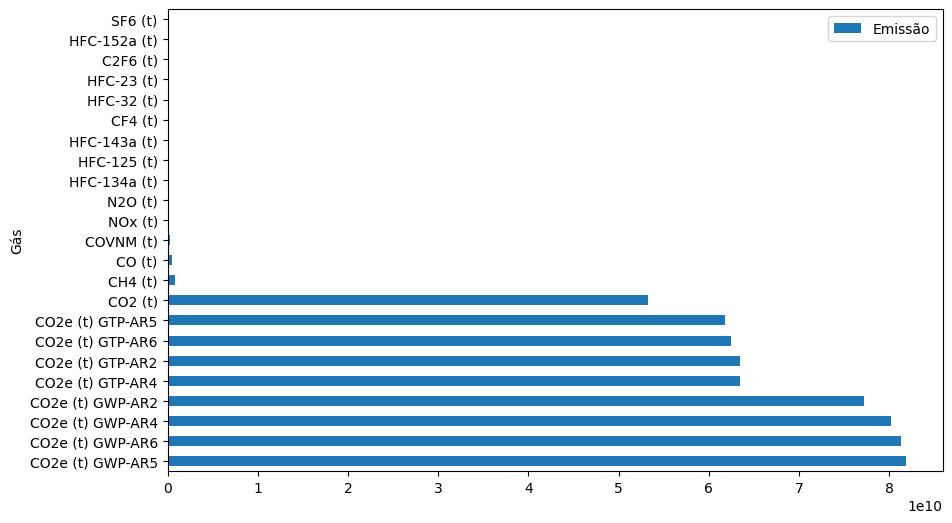

In [35]:
emissao_por_gas.plot(kind = 'barh', figsize = (10,6));

Conseguimos obter um gráfico que nos mostra a informação de uma melhor maneira se comparado à tabela. Na tabela não conseguíamos identificar tão bem quanto o CO₂ emitia a mais que os outros gases. Enquanto no gráfico, ficou evidente que os gases do tipo CO₂ emitem muito mais que os demais gases.

A barra dos outros gases (como SF₆ e C₂F₆) fica quase inexistente quando comparada ao CO₂. Isso não quer dizer que não existe emissão desses demais gases, mas que a emissão de gás carbônico é tão grande que a barra dos outros gases não fica visível.

Comparando a emissão em porcentagem
Agora, vamos obter uma métrica para identificar o quanto de CO₂ é emitido em comparação aos demais gases em porcentagem.

Como podemos obter isso? Primeiro, vamos selecionar somente os gases do tipo CO₂. Na nossa tabela em ordem decrescente, esses gases vão do primeiro ao nono valor, ou seja, do índice 0 ao 8.

Em outras palavras, se selecionamos os dados de 0 a 8, vamos obter o valor de emissão dos gases do tipo CO₂. Em uma nova célula, vamos escrever essa seleção.

Digitaremos o nome da tabela emissao_por_gas, seguido de ponto e do método iloc[]. Entre os colchetes, colocamos 0 e 9 separados por dois-pontos.

Colocamos até 9 porque o último valor de índice não aparece na seleção. É como se selecionássemos do zero ao oito.

In [36]:
emissao_por_gas.iloc[0:9]

,Emissão
Gás,
CO2e (t) GWP-AR5,8.181375e+10
CO2e (t) GWP-AR6,8.132316e+10
CO2e (t) GWP-AR4,8.015921e+10
CO2e (t) GWP-AR2,7.720596e+10
CO2e (t) GTP-AR4,6.344612e+10
CO2e (t) GTP-AR2,6.344612e+10
CO2e (t) GTP-AR6,6.247859e+10
CO2e (t) GTP-AR5,6.182200e+10
CO2 (t),5.324636e+10


Obtivemos os valores de emissão de cada um dos tipos de CO₂ que existem na base de dados.

Agora, vamos pegar essa soma de emissão de gás carbônico e dividir pela emissão total de todos os gases. Dessa forma, teremos a porcentagem de emissão de CO₂ em relação aos demais gases.

Vamos colocar esse cálculo em um print() para devolver a informação em texto para a equipe de supervisão.

Em uma nova célula, vamos escrever print(). Entre parênteses, escrevemos o f para concatenar a string A emissão de CO2 corresponde a com o resultado entre chaves da operação que vamos escrever. A operação será a soma da emissão de CO₂ dividida pela soma da emissão de todos os gases.

Primeiro, entre chaves, vamos escrever float(), pois queremos transformar o valor da operação em float (valor decimal). Entre os parênteses de float(), digitamos a operação.

Será a emissao_por_gas.iloc[0:9] para selecionar a emissão de todos os gases do tipo CO₂. Depois do .iloc, colocamos o método de soma .sum().

Em seguida, adicionamos uma barra para fazer a divisão. Agora, vamos colocar a soma de emissão de todos os gases, que será a tabela emissao_por_gas seguida do método sum() sem a seleção de nenhum dado.

A divisão irá nos trazer uma series que será um array. A partir dessa array, selecionaremos somente o primeiro dado, então vamos acrescentar .iloc[0] após o método sum()

Por fim, fora do float, vamos multiplicar esse valor por cem e colocar apenas duas casas decimais. Para isso, digitamos o símbolo de asterisco, seguido do número 100, dois-pontos e .2f.

In [37]:
print(f'A emissão de CO2 corresponde a {float((emissao_por_gas.iloc[0:9].sum()/emissao_por_gas.sum()).iloc[0])*100:.2f} % de emissão total de gases estufa no Brasil de 1970 a 2021.')

A emissão de CO2 corresponde a 99.74 % de emissão total de gases estufa no Brasil de 1970 a 2021.


Após executar a célula, esperamos como resultado um texto que mostra que a porcentagem da emissão do CO₂ em relação aos demais gases.

A emissão de CO2 corresponde a 99.74 % de emissão total de gases estufa no Brasil de 1970 a 2021.

Note como a emissão de gás carbônico é grande! Ela ocupa praticamente toda a emissão dos gases que temos no dataframe. Isso não quer dizer que não temos emissão dos demais gases, mas a emissão do CO₂ é mais expressiva.

Agora, já podemos passar essa informação e a tabela para a equipe de supervisão, para então prosseguir com a nossa análise.

Obtivemos os valores de emissão de cada um dos tipos de CO₂ que existem na base de dados.

Agora, vamos pegar essa soma de emissão de gás carbônico e dividir pela emissão total de todos os gases. Dessa forma, teremos a porcentagem de emissão de CO₂ em relação aos demais gases.

Vamos colocar esse cálculo em um print() para devolver a informação em texto para a equipe de supervisão.

Em uma nova célula, vamos escrever print(). Entre parênteses, escrevemos o f para concatenar a string A emissão de CO2 corresponde a com o resultado entre chaves da operação que vamos escrever. A operação será a soma da emissão de CO₂ dividida pela soma da emissão de todos os gases.

Primeiro, entre chaves, vamos escrever float(), pois queremos transformar o valor da operação em float (valor decimal). Entre os parênteses de float(), digitamos a operação.

Será a emissao_por_gas.iloc[0:9] para selecionar a emissão de todos os gases do tipo CO₂. Depois do .iloc, colocamos o método de soma .sum().

Em seguida, adicionamos uma barra para fazer a divisão. Agora, vamos colocar a soma de emissão de todos os gases, que será a tabela emissao_por_gas seguida do método sum() sem a seleção de nenhum dado.

A divisão irá nos trazer uma series que será um array. A partir dessa array, selecionaremos somente o primeiro dado, então vamos acrescentar .iloc[0] após o método sum()

Por fim, fora do float, vamos multiplicar esse valor por cem e colocar apenas duas casas decimais. Para isso, digitamos o símbolo de asterisco, seguido do número 100, dois-pontos e .2f.

Note como a emissão de gás carbônico é grande! Ela ocupa praticamente toda a emissão dos gases que temos no dataframe. Isso não quer dizer que não temos emissão dos demais gases, mas a emissão do CO₂ é mais expressiva.

Sobre o Groupby

O agrupamento de dados é uma aplicação muito utilizada para encontrar medidas resumidas e ter um entendimento maior dos dados. Com a biblioteca pandas, é possível utilizar o método groupby, que é um processo que ocorre através de diferentes etapas conhecidas como split-apply-combine ou dividir, aplicar e combinar, em português.

A etapa "dividir" consiste basicamente em separar o conjunto de dados em diferentes tabelas, uma para cada grupo. Os grupos são gerados a partir das categorias de uma ou mais colunas da tabela com base na informação que desejamos agrupar. Nesta etapa, podemos visualizar os grupos formados com o atributo groups e visualizar os dados de um grupo específico a partir do método get_group().

Já a etapa "aplicar" se refere ao momento de utilizar uma função matemática nos dados de cada grupo separadamente. Se o desejo for encontrar o valor total de cada grupo, então a soma será aplicada a cada grupo; se quisermos o valor médio, a função média será aplicada a cada grupo, e assim por diante. Existem diversas funções que podem ser aplicadas e cada uma dependerá do objetivo de análise dos dados:

mean() : calcula a média dos grupos
sum() : calcula a soma dos valores do grupo
size() : calcula tamanhos de grupo
count() : calcula a contagem do grupo
std() : desvio padrão de grupos
var() : calcula a variação de grupos
sem() : erro padrão da média dos grupos
describe() : gera estatísticas descritivas
first() : calcula o primeiro dos valores do grupo
last() : calcula o último dos valores do grupo
nth() : pega o n-ésimo valor do grupo
min() : calcula o mínimo de valores do grupo
max() : calcula o máximo de valores do grupo
Por fim, a etapa "combinar" consiste em juntar todas as informações de agregação de cada grupo em uma única tabela, contendo o resumo das informações. A partir dela e com o resultado final, é possível extrair insights a partir dos dados e fazer comparações dos resultados entre cada grupo.



Desafio:

Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para visualizar o dicionário contendo as chaves de grupos formados e a lista de índices de cada grupo.

Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" e localize os dados do grupo "Agropecuária".

Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para identificar a média de emissão de cada setor no ano de 2021.

Faça um agrupamento de dados com base na coluna "Nível 1 - Setor" para identificar a soma de emissão de cada setor. Ordene os dados da maior para menor emissão.

1) O agrupamento de dados pode ser feito utilizando o método groupby() e os grupos criados podem ser visualizados utilizando o atributo groups:



In [38]:
emissoes_por_ano.groupby('Nível 1 - Setor').groups

{'Agropecuária': [1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180, 1181, 1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192, 1193, 1194, 1195, 1196, 1197, 1198, 1199, 1200, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, ...], 'Energia': [23277, 23278, 23279, 23280, 23281, 23282, 23283, 23284, 23285, 23286, 23287, 23288, 23289, 23290, 23291, 23292, 23293, 23294, 23295, 23296, 23297, 23298, 23299, 23300, 23301, 23302, 23303, 23304, 23305, 23306, 23307, 23308, 23309, 23310, 23311, 23312, 23313, 23314, 23315, 23316, 23317, 23318, 23319, 23320, 23321, 23322, 23323, 23324, 23325, 23326, 23327, 23328, 

2) Para selecionar os dados de um grupo específico gerado pelo método groupby(), podemos usar o get_group():



In [39]:
emissoes_por_ano.groupby('Nível 1 - Setor').get_group('Agropecuária')

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
1137,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),AC,AGR,ALIM_BEBIDAS,1970,0.000000
1138,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),AL,AGR,ALIM_BEBIDAS,1970,2050.445805
1139,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),AM,AGR,ALIM_BEBIDAS,1970,0.000000
1140,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),AP,AGR,ALIM_BEBIDAS,1970,0.000000
1141,Agropecuária,Cultivo de Arroz,Diretas,Outros,Vegetal,Arroz,CH4 (t),BA,AGR,ALIM_BEBIDAS,1970,466.934705
...,...,...,...,...,...,...,...,...,...,...,...,...
4855420,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,N2O (t),RS,AGR,ALIM_BEBIDAS,2021,929.545042
4855421,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,N2O (t),SC,AGR,ALIM_BEBIDAS,2021,295.813919
4855422,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,N2O (t),SE,AGR,ALIM_BEBIDAS,2021,32.734589
4855423,Agropecuária,Solos Manejados,Indiretas,Mineralização de N associado a perda de C no solo,Outros,Solos,N2O (t),SP,AGR,ALIM_BEBIDAS,2021,653.155812


3) Para encontrar a média de emissão apenas dos dados do ano de 2021, primeiro é necessário filtrar a base de dados, depois agrupar os dados pela atividade econômica e utilizar o comando mean():

In [40]:
emissoes_por_ano[emissoes_por_ano['Ano']==2021].groupby('Nível 1 - Setor')[['Emissão']].mean()

,Emissão
Nível 1 - Setor,
Agropecuária,149793.768835
Energia,72928.637234
Mudança de Uso da Terra e Floresta,690085.511209
Processos Industriais,787101.255789
Resíduos,106106.723386


4) Para encontrar a soma da emissão por atividade econômica, é só utilizar o groupby(), seguido do método sum(). Por fim, os dados podem ser ordenados com a função sort_values():



In [41]:
emissoes_por_ano.groupby('Nível 1 - Setor')[['Emissão']].sum().sort_values('Emissão', ascending = False)

,Emissão
Nível 1 - Setor,
Mudança de Uso da Terra e Floresta,3.524898e+11
Energia,1.205314e+11
Agropecuária,1.147284e+11
Processos Industriais,2.849965e+10
Resíduos,1.034465e+10


Agora que sabemos quais os gases mais emitidos, vamos em busca de duas informações para a equipe de supervisão. Vamos encontrar:

Quais as atividades econômicas mais poluentes para cada tipo de gás;
E quais são os gases mais poluentes para cada atividade econômica.
Encontraremos essas informações usando agrupamento de dados. Entretanto, usaremos um agrupamento um pouco diferente: ao invés de agruparmos usando somente uma coluna do dataframe, utilizaremos duas colunas simultaneamente:

"Gás";
E "Nível 1 - Setor"
Em uma célula, vamos fazer esse agrupamento e armazenar esse resultado em uma variável chamada de gas_por_setor. Escrevemos, então, gas_por_setor = emissoes_por_ano.groupby() passando a lista de valores, sendo as duas colunas que vamos realizar o agrupamento.

Para inserir uma lista, abrimos e fechamos colchetes e dentro dele digitamos 'Gás' como primeiro elemento, e depois 'Nível 1 - Setor' que contém as informações das atividades econômicas na nossa base de dados.

Na sequência, colocamos a coluna "Emissão" entre aspas simples e duplo colchetes. Depois utilizamos o método .sum() para somar as emissões para cada gás e cada atividade econômica.

Finalizamos a célula com gas_por_setor.

### Emissão de gases por setor

Agora vamos em busca de duas informações:

- Descobrir quais são os setores mais poluentes para cada gás;
- Descobrir quais são os gases mais poluentes para cada setor.

In [42]:
gas_por_setor = emissoes_por_ano.groupby(['Gás', 'Nível 1 - Setor'])[['Emissão']].sum()
gas_por_setor

Emissão
Gás      Nível 1 - Setor                                 
C2F6 (t) Processos Industriais               5.765018e+02
CF4 (t)  Processos Industriais               7.135481e+03
CH4 (t)  Agropecuária                        5.928481e+08
         Energia                             3.429034e+07
         Mudança de Uso da Terra e Floresta  8.662166e+07
...                                                   ...
N2O (t)  Resíduos                            2.764127e+05
NOx (t)  Agropecuária                        2.602719e+06
         Energia                             9.361215e+07
         Processos Industriais               3.546360e+06
SF6 (t)  Processos Industriais               4.705800e+02

[72 rows x 1 columns]

A nossa primeira informação é a dos gases, assim como passamos na ordem da lista no groupBy(), e a segunda informação é o Nível 1 - Setor, sendo a informação da atividade econômica.

Essa ordem dos índices é importante para localizar os dados no nosso dataframe. O gás, como primeiro índice, está localizado no level zero de índice. Já o nível 1 - Setor está no level 1 do dataframe.

Assim, para localizar os setores econômicos com maior emissão para cada tipo de gás, precisamos selecionar o gás e identificar qual a atividade mais poluente para ele.

Para entendermos como devemos solucionar o problema, vamos primeiro selecionar as informações sobre o gás CO2 (dióxido de carbono) e identificar o agrupamento feito para essa informação.

Para selecionar apenas os dados do CO2, usamos o método cross-section ou xs da biblioteca Pandas. Em uma nova célula, escrevemos gas_por_setor.xs() passando qual índice desejamos localizar. No caso, é a informação do gás CO2 e na sequência passamos o level ao qual a informação pertecence.

É importante identificar a ordem dos índices, para identificar em qual level essa informação está localizada.


Como o gás se encontra na informação de level 0, colocamos no parâmetro level = 0.



Para descobrir o setor que emite a maior quantidade de CO2, podemos realizar uma seleção específica do gás CO2 com o uso do método *cross-section* [`xs()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.xs.html), extraindo a partir disso o valor máximo e índice máximo com os métodos [`max()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.max.html) e [`idxmax()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.idxmax.html?highlight=idxmax#pandas.DataFrame.idxmax).

In [43]:
gas_por_setor.xs('CO2 (t)', level = 0)

,Emissão
Nível 1 - Setor,
Agropecuária,5.411750e+08
Energia,1.261352e+10
Mudança de Uso da Terra e Floresta,3.733930e+10
Processos Industriais,2.729603e+09
Resíduos,2.276264e+07


Obtemos o agrupamento de todas as atividades econômicas, então temos a soma de emissão para cada uma das atividades, mas apenas do gás CO2.

A partir da tabela, conseguimos verificar que a Mudança de Uso da Terra e Floresta é a atividade com maior emissão desse gás.

Para selecionar essa informação de forma manual usando o cross-section, usamos o mesmo código que rodamos anteriormente, mas ao invés de passar somente o CO2, passamos uma tupla de valores.

Como primeiro parâmetro da tupla passamos o 'CO2 (t)', depois colocamos uma vírgula e passamos como segundo parâmetro o Mudança de Uso da Terra e Floresta.

A ordem das informações é importante quando usamos o cross-section!

Como a informação de CO2 está no level 0 e a Mudança de Uso da Terra e Floresta está no level 1, colocamos uma vírgula após o primeiro fechamento de parênteses e passamos os valores na ordem da tupla, ou seja, level = [0,1].

Dessa forma, indicamos que queremos localizar a informação com nome 'CO2 (t)' no level 0 do dataframe multi-index, e a informação 'Mudança de Uso da Terra e Floresta' corresponderá ao level 1.

Como retorno, obtemos o resultado da emissão de CO2 para a mudança de uso da terra e floresta:

In [44]:
gas_por_setor.xs(('CO2 (t)', 'Mudança de Uso da Terra e Floresta'), level = [0,1])

,,Emissão
Gás,Nível 1 - Setor,
CO2 (t),Mudança de Uso da Terra e Floresta,3.733930e+10


Entretanto, aplicamos isso de forma bem manual. Selecionamos os dados do agrupamento de CO2, identificamos visualmente na tabela qual a emissão máxima, e selecionamos com o cross-section como podemos selecionar para o CO2 o setor de atividade econômica que possui maior emissão.

Porém, é possível fazer o mesmo processo de forma mais automática. Utilizando o método .max(), conseguimos localizar o maior valor de emissão de determinada atividade econômica para um gás específico.

Em uma nova célula, vamos escrever gas_por_setor.xs novamente, mas dessa vez passaremos o parâmetro level = 0 no lugar de 'Mudança de Uso da Terra e Floresta'. Dessa forma, iremos localizar a mesma tabela que em que identificamos cada um dos setores econômicos para o gás CO2.

Por fim, vamos incluir um ponto e o método max().

Executando a célula, obtemos justamente o valor 3.733930e+10.

In [45]:
gas_por_setor.xs('CO2 (t)', level = 0).max()

,0
Emissão,3.733930e+10


No entanto, perceba que não temos o nome da atividade econômica, informação que também é interessante para a equipe de supervisão.

Para localizá-la, vamos copiar o código da célula anterior e, em vez de usar o método max(), utilizaremos o idxmax(). Com isso, será devolvido o nome da atividade econômica com maior valor de emissão.

In [46]:
gas_por_setor.xs('CO2 (t)', level = 0).idxmax()

,0
Emissão,Mudança de Uso da Terra e Floresta


Contudo, ainda estamos manipulando os dados de forma bastante manual: escrevemos o nome do gás desejado e identificamos o nome da atividade econômica. Se quiséssemos fazer essa localização para cada um dos gases, seria necessário fazer o mesmo processo várias vezes.

Como podemos selecionar essas informações de forma automática?

Um DataFrame multi Index é uma estrutura de dados em pandas que permite a criação de um índice hierárquico, isto é, com um índice que possui múltiplos níveis. Isso permite a organização dos dados de maneira mais detalhada do que um índice simples e pode ser verificado no exemplo abaixo de um DataFrame multi index, no qual as duas primeiras colunas representam os 2 níveis do index:

A hierarquia dos índices é da esquerda para a direita, portanto o índice "Gás" ocupa o level 0 de hierarquia e o índice "Nível 1 - Setor" ocupa o level 1 de hierarquia. A seleção de dados a partir dos índices nesse tipo de DataFrame se torna um pouco diferente de um convencional. Podemos usar o método loc para selecionar os dados do primeiro level de forma direta. Logo, para selecionar as informações do gás "CH4", é possível utilizar o código:

Para evitar uma forma manual para cada tipo de gás, podemos explorar ainda mais o método `groupby()` em conjunto com o [`idxmax()`](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.idxmax.html?highlight=idxmax#pandas.core.groupby.DataFrameGroupBy.idxmax).

In [47]:
gas_por_setor.loc['CH4 (t)']

,Emissão
Nível 1 - Setor,
Agropecuária,5.928481e+08
Energia,3.429034e+07
Mudança de Uso da Terra e Floresta,8.662166e+07
Processos Industriais,2.092132e+06
Resíduos,7.907453e+07


Já para selecionar valores específicos de algum dos níveis do índice, é preciso utilizar o método xs(), conhecido como cross-section. Com ele, há a possibilidade de selecionar um valor de um nível de hierarquia sem a necessidade de indicar a tupla desde o primeiro level. Para selecionar os valor "Agropecuária" na tabela, podemos usar o código:

In [48]:
gas_por_setor.xs('Agropecuária', level = 1)

,Emissão
Gás,
CH4 (t),5.928481e+08
CO (t),7.132479e+07
CO2 (t),5.411750e+08
CO2e (t) GTP-AR2,8.297112e+09
CO2e (t) GTP-AR4,8.297112e+09
CO2e (t) GTP-AR5,7.065371e+09
CO2e (t) GTP-AR6,7.462618e+09
CO2e (t) GWP-AR2,1.849256e+10
CO2e (t) GWP-AR4,2.065099e+10


Por fim, podemos criar uma tabela sumarizada com as informações dos valores máximos de emissão para cada tipo de gás e com a referência do setor com maior emissão de cada gás.

In [49]:
gas_por_setor.groupby(level = 0).idxmax()

,Emissão
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


Criamos uma tabela com os dados agrupados da emissão para cada tipo de gás e atividade econômica. Entretanto, essa tabela não responde à pergunta feita pela equipe de supervisão.

Para encontrar essa resposta, precisamos realizar outro agrupamento nessa tabela que já agrupamos anteriormente. Temos uma tabela multi index nesse dataframe e a informação no nível 0 do índice (a informação gás) é a que vamos usar para agrupar os dados. Assim encontramos a atividade econômica que possui maior emissão para cada tipo de gás.

Voltando ao código, na primeira célula, escrevemos gas_por_setor.groupby(level = 0), sendo a informação do gás. Isto é, nossos dados serão agrupados baseado no gás. Agora desejamos passar o método de agrupamento por idxmax() (índice onde há a maior emissão, será o nome da atividade econômica).

In [50]:
gas_por_setor.groupby(level = 0).max()

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),5.928481e+08
CO (t),3.959769e+08
CO2 (t),3.733930e+10
CO2e (t) GTP-AR2,3.850044e+10
CO2e (t) GTP-AR4,3.850044e+10
CO2e (t) GTP-AR5,3.831675e+10
CO2e (t) GTP-AR6,3.843359e+10


In [51]:
valores_max = gas_por_setor.groupby(level = 0).max().values

In [52]:
tabela_sumarizada = gas_por_setor.groupby(level = 0).idxmax()
tabela_sumarizada.insert(1,'Quantidade de Emissão', valores_max)
tabela_sumarizada

,Emissão,Quantidade de Emissão
Gás,,
C2F6 (t),"(C2F6 (t), Processos Industriais)",5.765018e+02
CF4 (t),"(CF4 (t), Processos Industriais)",7.135481e+03
CH4 (t),"(CH4 (t), Agropecuária)",5.928481e+08
CO (t),"(CO (t), Energia)",3.959769e+08
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)",3.733930e+10
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F...",3.831675e+10
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F...",3.843359e+10


Obtemos a tabela sumarizada, temos as informações de cada gás, a atividade econômica que mais emite o gás e qual a quantidade de emissão. Com isso, temos a tabela que pode ser enviada o time de supervisão, mas **precisamos gerar outra tabela.

Nessa tabela, para cada uma das 5 atividades econômicas que existem no nosso banco de dados, vamos encontrar quais são os gases que mais emitem para cada uma delas.

A princípio nossa tabela tinha o índice 0 como gás, e o índice 1 como o nível 1 - setor. Vamos trocar a posição desses índices usando o mesmo código, dessa forma vamos obter a informação invertida: os gases que mais emitem para cada uma das 5 atividades econômicas.

Na célula seguinte, vamos usar a função swaplevel(), que nos permite inverter um nível de índice com outro. Escrevemos gas_por_setor.swaplevel() passando qual level desejamos trocar com outro, então basta colocarmos 0,1.

Podemos alterar a ordem dos níveis de índice para encontrar a outra informação, que nos diz qual o gás mais emitido para cada tipo de setor. Para isso, vamos utilizar o método [`swaplevel()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.swaplevel.html).

In [53]:
gas_por_setor.swaplevel(0,1)

Emissão
Nível 1 - Setor                    Gás                   
Processos Industriais              C2F6 (t)  5.765018e+02
                                   CF4 (t)   7.135481e+03
Agropecuária                       CH4 (t)   5.928481e+08
Energia                            CH4 (t)   3.429034e+07
Mudança de Uso da Terra e Floresta CH4 (t)   8.662166e+07
...                                                   ...
Resíduos                           N2O (t)   2.764127e+05
Agropecuária                       NOx (t)   2.602719e+06
Energia                            NOx (t)   9.361215e+07
Processos Industriais              NOx (t)   3.546360e+06
                                   SF6 (t)   4.705800e+02

[72 rows x 1 columns]

Obtemos a mesma tabela, mas desta vez invertendo a ordem do nível 1 setor com o gás. Agora temos um dataframe em que a informação da atividade econômica ocupa a mesma posição do índice.

Assim, podemos usar essa nossa nova tabela de gás por setor com o swaplevel() e usar o mesmo groupby() com o level 0. Porque agora a atividade está no nível 0. Após o gas_por_setor.swaplevel(0, 1) colocamos .groupby(level = 0) e depois .idxmax().

In [54]:
gas_por_setor.swaplevel(0,1).groupby(level = 0).idxmax()

,Emissão
Nível 1 - Setor,
Agropecuária,"(Agropecuária, CO2e (t) GWP-AR5)"
Energia,"(Energia, CO2e (t) GWP-AR6)"
Mudança de Uso da Terra e Floresta,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
Processos Industriais,"(Processos Industriais, CO2e (t) GWP-AR6)"
Resíduos,"(Resíduos , CO2e (t) GWP-AR5)"


Temos os gases que mais emitem para cada atividade. Como o CO2 é gás que emite uma maior quantidade, tivemos como retorno somente esse gás. Assim, cada atividade econômica terá um tipo de gás CO2 que mais emite.

Na agropecuária, por exemplo, emite o GWP-AR5. Sendo o tipo de CO2 que mais emite na agropecuária.

Agora, podemos enviar esses dados para a equipe de supervisão. Entretanto, ela solicitou outro tipo de informação: encontrar qual a variação da emissão ao longo de todos os anos.

### Emissão ao longo dos anos

Vamos identificar se as emissões de gases estufas aumentaram ou diminuíram ao longo dos anos e visualizar essa variação para cada tipo de gás emitido separadamente.

In [55]:
emissoes_por_ano

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4926891,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR5,MS,AGROPEC,NaN,2021,1004191.0
4926892,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MT,AGROPEC,NaN,2021,443120.0
4926893,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,CO2e (t) GWP-AR6,MS,AGROPEC,NaN,2021,1009968.0
4926894,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,N2O (t),MT,AGROPEC,NaN,2021,479.0


Com isso, conseguimos visualizar o dataframe. As informações que vamos precisar para criar um gráfico de emissão média ao longo dos anos é: a coluna para o ano e também emissão. Porém, temos a informação de ano repetida nas linhas da tabela.

Por isso, para construir esse gráfico, precisamos agrupar os dados com base na coluna ano. A partir daí, vamos extrair a média de emissão de cada ano. Para isso, utilizamos o método groupby().

Na célula seguinte, digitamos emissoes_por_ano.groupby(), onde vamos escrever a coluna que possui as informações que queremos agrupar. No nosso caso, é a coluna Ano entre aspas simples.

Em seguida, vamos ter que selecionar a coluna que contém os dados numéricos para extrair a média, a qual será a coluna de Emissão. Por isso, colocamos Emissão entre colchetes duplos.

Também vamos acrescentar .mean() para ter a média dos valores. Sabemos qual será o resultado: um dataframe com cada ano nos índices e na coluna vamos ter o dado da emissão média.

Assim, ao final desse código, vamos colocar o .plot() para criar um gráfico de linhas. Além disso, vamos alterar o tamanho do gráfico com o parâmetro figsize. Dentro dos parênteses de plot, digitamos figsize igual a uma tupla de (10, 6). Por fim, colocamos ponto e vírgula para não ser exibida nenhuma informação textual acima do gráfico.

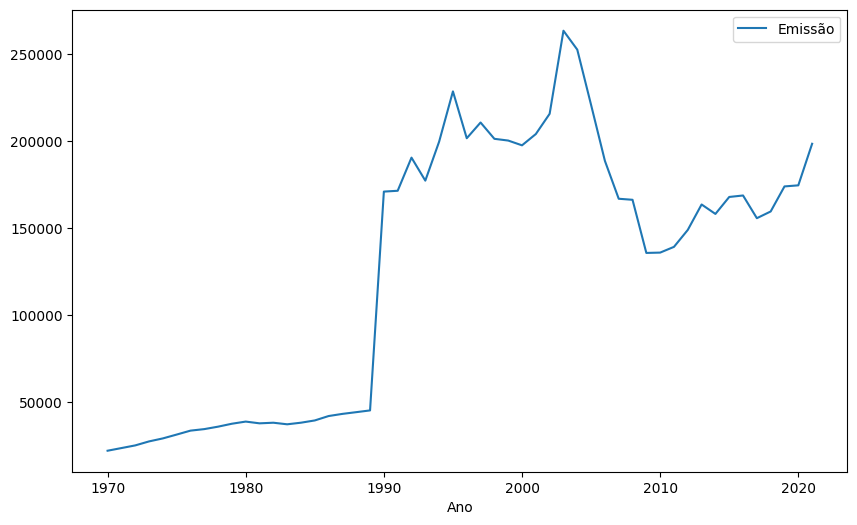

In [56]:
emissoes_por_ano.groupby('Ano')[['Emissão']].mean().plot(figsize = (10, 6));

Com isso, temos o gráfico de linhas da média de emissões ao longo dos anos. No eixo x temos os anos de 1970 até 2021 e no eixo y temos a média de emissão para cada um desses anos. Perceba que do ano de 1970 até 1990, o gráfico teve um crescimento lento da média de emissões.

Mas, a partir de 1990, tivemos um salto na média de emissão. Esse salto tem uma justificativa: os dados fornecidos pelo SRG nos traz as mudanças do uso da terra e florestas somente a partir desse ano. Por isso, foram adicionados novos registros na tabela e aumentou a média de emissão.

De 1990 até por volta de 2000, tivemos um crescimento da média de emissão, mas a partir de 2000 houve um decrescimento significativo até 2010 e posteriormente voltou a aumentar até o ano de 2020.

Média máxima de emissão
Vamos encontrar o valor de emissão média máxima no gráfico e descobrir em qual ano aconteceu, utilizando o idxmax() que consegue extrair o índice com o valor máximo.

Podemos copiar o código que fizemos até o mean() para extrair a média, e colar na célula abaixo. No final, adicionamos .idxmax(), assim obtemos o índice que possui emissão máxima no nosso dataframe.

Pelo fato do índice corresponder ao ano e a coluna ter o valor da emissão, vamos encontrar o valor do ano.

Indica que o ano com a maior média de emissão foi 2003. Foi o pico do gráfico.

Gráfico de média de emissão por ano e gás
Já conseguimos construir o gráfico de emissão média ao longo dos anos e também obtivemos o ano com a maior média de emissão. Entretanto, a equipe de supervisão deseja saber a emissão média ao longo dos anos para cada tipo de gás separadamente.

Primeiro, precisamos utilizar o groupby() a partir de duas colunas simultaneamente: as colunas de ano e gás. Na próxima célula, vamos fazer esse agrupamento para criar uma tabela com os dados de emissão média tanto por ano quanto pelo tipo de gás.

Escrevemos emissoes_por_ano.groupby([]), os colchetes significa que estamos passando uma lista, onde o primeiro elemento será o Ano entre aspas simples e o segundo elemento será o Gás também entre aspas simples.

Também devemos selecionar entre colchetes duplos a coluna que queremos extrair a média de valores, a qual será a coluna Emissão. Por fim, colocamos o .mean() para visualizar a média dos valores.

In [57]:
emissoes_por_ano.groupby(['Ano', 'Gás'])[['Emissão']].mean()

Emissão
Ano  Gás                     
1970 C2F6 (t)        0.232610
     CF4 (t)         3.557421
     CH4 (t)      1471.024024
     CO (t)       2155.556658
     CO2 (t)     19244.913199
...                       ...
2021 HFC-23 (t)      0.000000
     HFC-32 (t)    261.100000
     N2O (t)       119.295311
     NOx (t)       679.395431
     SF6 (t)         5.240000

[1196 rows x 1 columns]

Temos um dataframe multi index, onde o primeiro level do índice foi o ano e o level 1 foi o gás. Por ter muitas informações, não foi exibida a tabela completa. Para converter esse dataframe para uma tabela interativa clicamos no ícone de varinha mágica localizado no canto superior direito da tabela. Esse ícone é nomeado como "Convert this dataframe to an interactive table".

Entretanto, desejamos passar esses dados para a equipe de supervisão em forma de gráfico. Para construir essa visualização, primeiro vamos resetar o índice para transformá-lo em novas colunas. Posteriormente aplicamos uma transformação para criar uma coluna para cada gás.

Assim, a informação do ano permanecerá nas linhas (no índice do dataframe), mas a coluna de gás se transformará em uma coluna para cada tipo de gás. Com isso, obtemos os valores de emissão para cada gás ao longo dos anos.

O primeiro passo é copiar o código anterior para armazenar essa tabela com os índices removidos, usando a função reset.index().

Na próxima célula, criamos a tabela de media_emissao_anual que será igual ao código que copiamos anteriormente. No final, acrescentamos o .reset.index(). Na mesma célula, colocamos media_emissao_anual e executamos.

In [58]:
media_emissao_anual = emissoes_por_ano.groupby(['Ano', 'Gás'])[['Emissão']].mean().reset_index()
media_emissao_anual

,Ano,Gás,Emissão
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1471.024024
3,1970,CO (t),2155.556658
4,1970,CO2 (t),19244.913199
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.295311
1194,2021,NOx (t),679.395431


É o mesmo dataframe, mas transformamos os índices em colunas. Assim, temos uma coluna para o ano e uma para o gás, pois não são mais os índices do dataframe.

Agora, vamos utilizar o método pivot_table() para transformar a coluna de gás em novas colunas. Assim, obtemos um dataframa com os anos nos índices, as colunas com cada gás e os valores são as emissões.

Em uma nova célula, colocamos media_emissao_anual igual à media_emissao_anual.pivot_table(). Vamos passar três parâmetros para esse método.

O primeiro parâmetro é o índice que desejamos que tenha nessa tabela, no caso é o ano. Logo escrevemos index igual à Ano entre aspas simples. Assim, a coluna ano irá se transformar em uma informação de índice.

Como segundo parâmetro do pivot_table() passamos as colunas que desejamos que sejam exibidas no dataframe. No caso, colocamos columns igual à Gás entre aspas simples. Por fim, passamos os valores numéricos que estarão em cada uma das colunas, colocamos values igual à Emissão entre aspas simples.

Na mesma célula, passamos o media_emissao_anual para visualizar o resultado


In [59]:
media_emissao_anual = media_emissao_anual.pivot_table(index = 'Ano', columns = 'Gás', values = 'Emissão')
media_emissao_anual

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
Ano,,,,,,,,,,,,,,,,,,,,,
1970,0.232610,3.557421,1471.024024,2155.556658,19244.913199,20821.379814,20821.379814,19162.726020,19775.283385,35396.183865,...,742.074863,0.000000,0.000000,0.000000,0.0,0.00,0.00,31.632709,154.072797,0.000
1971,0.334611,5.117360,1525.506914,2259.625805,21598.587743,22466.288595,22466.288595,20748.481445,21386.175802,37570.982886,...,730.119047,0.000000,0.000000,0.000000,0.0,0.00,0.00,32.609237,170.550178,0.000
1972,0.404684,6.189025,1584.719568,2418.944795,23664.445521,24100.305265,24100.305265,22303.224240,22966.797327,39800.768350,...,774.278817,0.000000,0.000000,0.000000,0.0,0.00,0.00,34.311864,188.856161,0.000
1973,0.463147,7.083136,1642.612439,2596.053853,27726.668829,26683.827206,26683.827206,24827.077028,25516.409611,42947.755490,...,796.866394,0.000000,0.000000,0.000000,0.0,0.00,0.00,35.278689,217.320480,0.000
1974,0.471026,7.203619,1704.614365,2681.450599,30155.918952,28539.318732,28539.318732,26600.481407,27321.124852,45431.240064,...,1024.694923,0.000000,0.000000,0.000000,0.0,0.00,0.00,37.098183,247.521415,0.000
1975,0.502952,7.691893,1854.360821,2730.894830,32292.965771,30593.767465,30593.767465,28507.669059,29285.642221,48944.729581,...,1065.682750,0.000000,0.000000,0.000000,0.0,0.00,0.00,39.451008,262.716346,0.000
1976,0.577172,8.826970,1932.641716,2702.494362,35640.344723,33066.878007,33066.878007,30879.481709,31693.226162,52203.028009,...,1091.778909,0.000000,0.000000,0.000000,0.0,0.00,0.00,41.583225,287.013048,0.000
1977,0.692855,10.596169,1931.897645,2675.992077,37313.909077,34182.312333,34182.312333,31967.243034,32784.131397,53333.605735,...,1147.712448,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.571086,292.405821,0.000
1978,0.749660,11.464915,1921.281930,2755.891877,40669.820049,35969.633601,35969.633601,33762.778999,34580.720998,55015.291182,...,1289.853564,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.426649,322.982906,0.000


Temos a informação do índice como cada ano, enquanto cada coluna corresponde a um gás. Com isso, obtemos a emissão para cada gás e para cada ano separadamente.

Para criar um gráfico para um dos gases, basta usar essa tabela media_emissao_anual com o método plot(), passando um parâmetro adicional chamado subplots igual à True. Com isso, vamos construir um gráfico para cada coluna da tabela.

Como segundo parâmetro, alteramos o tamanho do gráfico com o método figsize igual à tupla (10, 40), sendo 10 a altura e o comprimento 40. Por fim, colocamos ; para não exibir nenhuma informação textual.

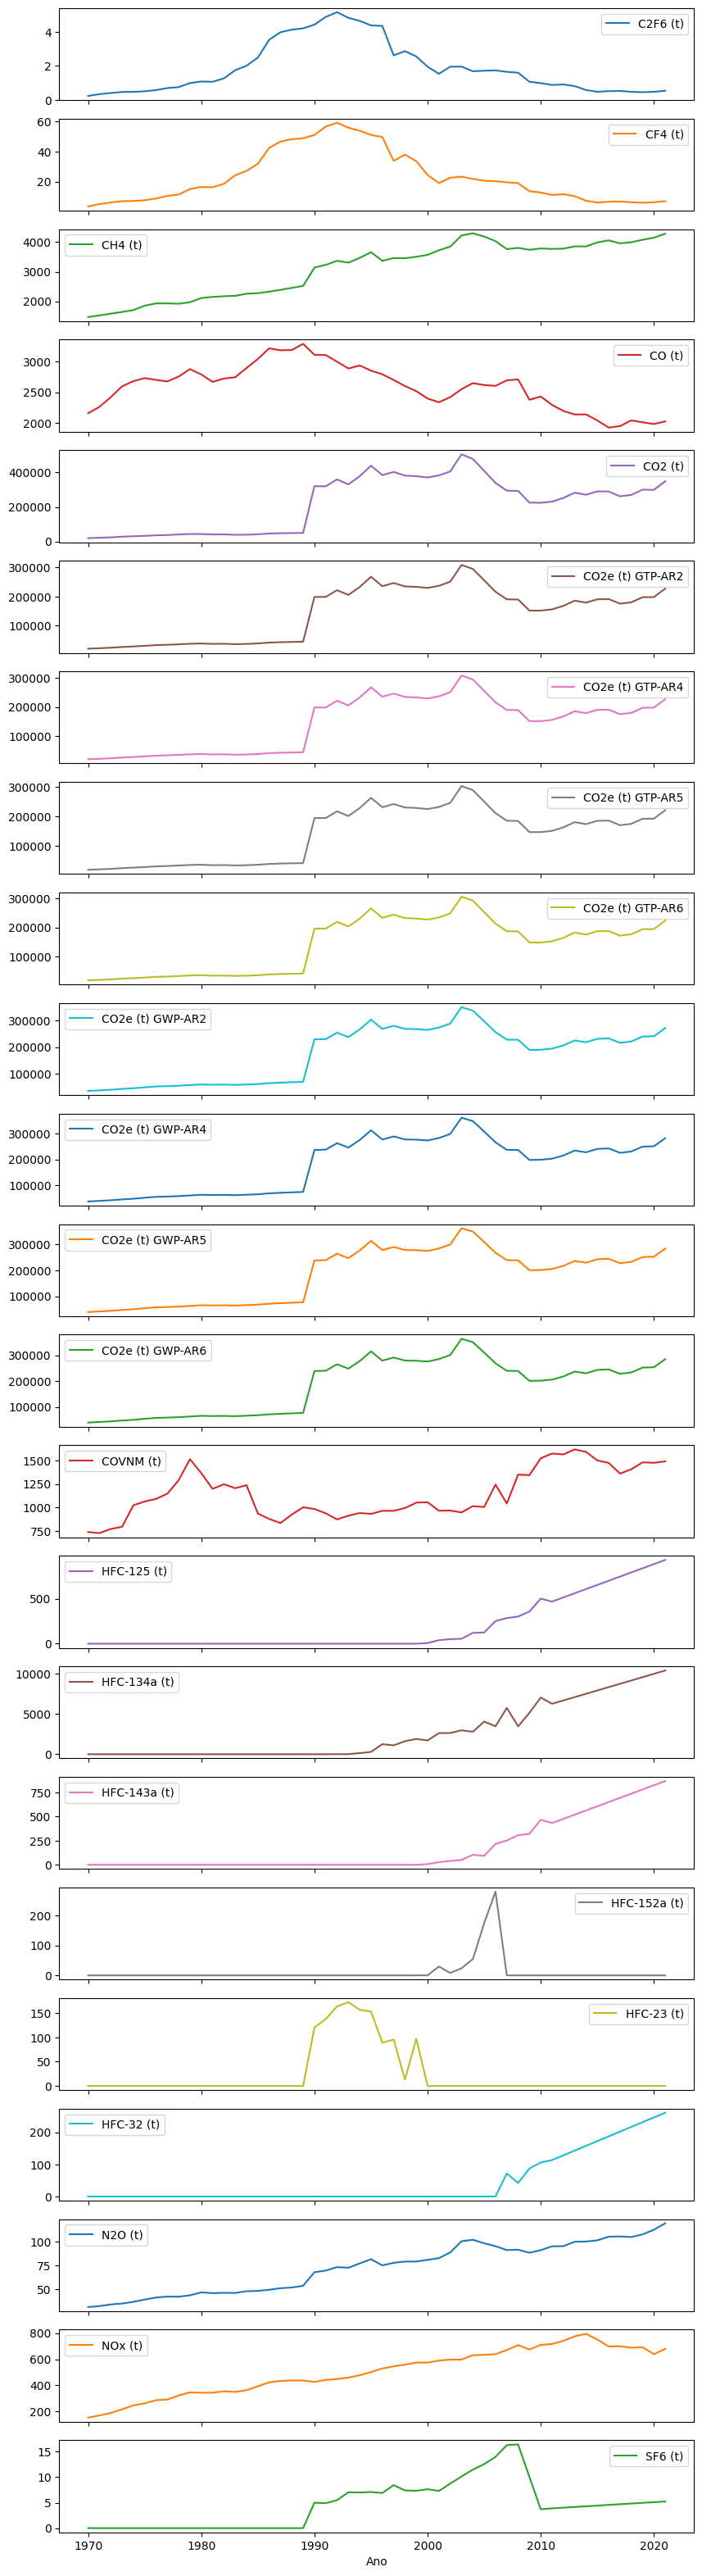

In [60]:
media_emissao_anual.plot(subplots = True, figsize = (10, 40));

Com isso, obtivemos a média de emissão de 1970 até 2021 para cada tipo de gás da base de dados.

A partir de agora a equipe de supervisão consegue identificar o padrão de cada gás separadamente, além do padrão da média de emissão global de todos os gases que construímos anteriormente.

Por exemplo, o C2F6 teve um crescimento até um determinado ano e depois teve um decrescimento da média de emissão. Já o CH4 teve somente um crescimento ao longo dos anos.

A equipe de supervisão pode utilizar essas informações para sua análise. Vamos prosseguir com as últimas análises do projeto na próxima aula.

Desafio:

Uma das tarefas passadas pela equipe de supervisão do órgão ambiental era de encontrar a emissão média de cada gás por ano. Conseguimos realizar essa tarefa usando o método groupby() e pivot_table() para gerar uma tabela contendo a emissão ao longo dos anos para cada um dos gases.

A equipe de supervisão deseja saber agora a média de emissão para cada um dos setores econômicos da coluna "Nível 1 - Setor" ao longo dos anos. Como desafio, crie uma tabela de pivô e uma visualização gráfica contendo essas informações, utilizando apenas o método pivot_table para a construção da tabela, sem utilizar o método groupby.

Você pode buscar informações de como fazer isso na documentação Pandas sobre o método pivot_table. https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html

In [61]:
emissao_setores = emissoes_por_ano.pivot_table(values = 'Emissão', index = 'Ano', columns = 'Nível 1 - Setor', aggfunc = 'mean')
emissao_setores

Nível 1 - Setor,Agropecuária,Energia,Mudança de Uso da Terra e Floresta,Processos Industriais,Resíduos
Ano,,,,,
1970,49292.425313,15939.703116,0.000000e+00,106549.168676,11684.883558
1971,51199.559433,17698.989894,0.000000e+00,111532.507753,12676.706849
1972,53508.935498,19092.876761,0.000000e+00,125701.525455,13709.697850
1973,55494.006224,22062.085929,0.000000e+00,137657.110402,14715.248028
1974,57896.513900,23810.659474,0.000000e+00,149941.779638,15710.616150
1975,63303.098508,25036.433686,0.000000e+00,168471.860169,16667.446706
1976,66347.533521,27214.281091,0.000000e+00,193826.482068,17539.505222
1977,66977.413505,27645.258640,0.000000e+00,231505.609283,18462.455148
1978,66640.432009,29734.461056,0.000000e+00,255736.210711,19327.840165


Com essas informações, basta utilizar o método plot() com o parâmetro subplots = True que irá construir um gráfico para cada uma das colunas de setores econômicos.

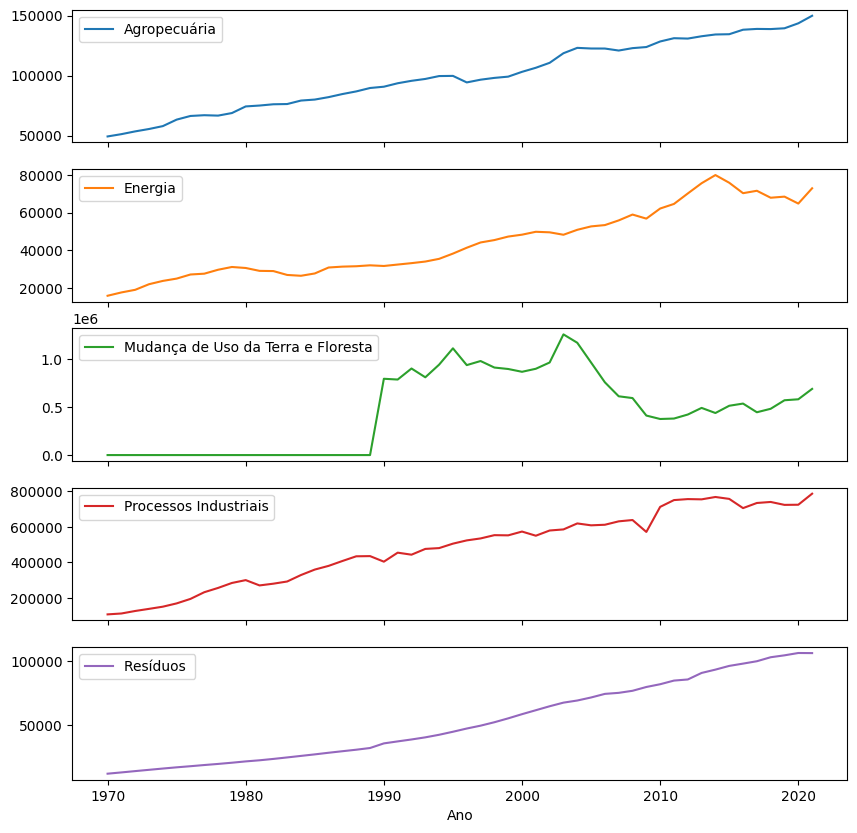

In [62]:
emissao_setores.plot(subplots = True, figsize = (10,10));

Desafio 2:
1) Faça um agrupamento de dados com as colunas "Estado" e "Nível 1 - Setor", obtendo a soma de emissão e armazenando o resultado em uma tabela.

2) Utilizando a tabela construída na atividade 1, selecione os dados referentes à "Energia" do índice "Nível 1 - Setor".

3) Utilizando a tabela construída na atividade 1, encontre a atividade econômica com valor máximo de emissão do Estado de Minas Gerais

4) Obtenha uma tabela contendo a atividade econômica com máxima emissão para cada Estado.

5) Obtenha uma tabela contendo o Estado com máxima emissão para cada atividade econômica.

Podem existir maneiras diferentes de chegar ao mesmo resultado em cada uma das atividades. Aqui estão opções para solucionar os problemas, mas não quer dizer que sejam a única resposta correta.

1) Para criar um agrupamento de 2 colunas, precisamos passar uma lista com os nomes das colunas de agrupamento para o método groupby e utilizar o método sum() para fazer a soma das emissões:

In [63]:
soma_emissao = emissoes_por_ano.pivot_table(values = 'Emissão', index = 'Estado', columns = 'Nível 1 - Setor', aggfunc = 'sum')
soma_emissao

Nível 1 - Setor,Agropecuária,Energia,Mudança de Uso da Terra e Floresta,Processos Industriais,Resíduos
Estado,,,,,
AC,7.270206e+08,2.071751e+08,7.847879e+09,NaN,2.928323e+07
AL,7.628303e+08,5.958697e+08,4.619358e+08,6.035868e+07,1.372234e+08
AM,5.480091e+08,1.916462e+09,1.549303e+10,6.577097e+07,2.095418e+08
AP,1.302005e+08,2.638059e+08,1.279214e+09,NaN,3.146253e+07
BA,6.878724e+09,4.801368e+09,1.121511e+10,5.279045e+08,5.870007e+08
CE,1.792303e+09,1.879584e+09,1.743343e+09,2.029116e+08,4.084013e+08
DF,9.409598e+07,9.487860e+08,7.590559e+07,2.808629e+08,1.513052e+08
ES,1.380415e+09,2.201326e+09,1.189567e+09,2.344011e+09,2.000138e+08
GO,1.187803e+10,2.761709e+09,7.163465e+09,1.716006e+08,3.164097e+08


2) Para selecionar um elemento de um DataFrame multi index, podemos usar o método cross-section, identificando o nível hierárquico do índice que estamos buscando. No caso, "Energia" é um valor do índice "Nível 1 - Setor" que ocupa o level 1 de hierarquia no DataFrame:



In [64]:
soma_emissao['Energia']

,Energia
Estado,
AC,2.071751e+08
AL,5.958697e+08
AM,1.916462e+09
AP,2.638059e+08
BA,4.801368e+09
CE,1.879584e+09
DF,9.487860e+08
ES,2.201326e+09
GO,2.761709e+09


3) Para selecionar o valor de índice com emissão máxima, devemos utilizar o cross-section em conjunto com o método idxmax():

In [65]:
soma_emissao.loc['MG'].idxmax()

'Agropecuária'

In [66]:
emissoes_estados_setor = emissoes_por_ano.groupby(['Estado', 'Nível 1 - Setor'])[['Emissão']].sum()
emissoes_estados_setor.groupby(level = 0).idxmax()

,Emissão
Estado,
AC,"(AC, Mudança de Uso da Terra e Floresta)"
AL,"(AL, Agropecuária)"
AM,"(AM, Mudança de Uso da Terra e Floresta)"
AP,"(AP, Mudança de Uso da Terra e Floresta)"
BA,"(BA, Mudança de Uso da Terra e Floresta)"
CE,"(CE, Energia)"
DF,"(DF, Energia)"
ES,"(ES, Processos Industriais)"
GO,"(GO, Agropecuária)"


In [67]:
emissoes_estados_setor.xs('Energia', level = 1)

,Emissão
Estado,
AC,2.071751e+08
AL,5.958697e+08
AM,1.916462e+09
AP,2.638059e+08
BA,4.801368e+09
CE,1.879584e+09
DF,9.487860e+08
ES,2.201326e+09
GO,2.761709e+09


4) Para conseguir o índice da atividade econômica de emissão máxima de cada Estado, devemos fazer um novo agrupamento de dados a partir do índice, indicando qual nível hierárquico e usando o método idxmax():

In [78]:
emissoes_estados_setor = emissoes_por_ano.groupby(['Estado', 'Nível 1 - Setor'])[['Emissão']].sum()
emissoes_estados_setor.groupby(level = 0).idxmax()

,Emissão
Estado,
AC,"(AC, Mudança de Uso da Terra e Floresta)"
AL,"(AL, Agropecuária)"
AM,"(AM, Mudança de Uso da Terra e Floresta)"
AP,"(AP, Mudança de Uso da Terra e Floresta)"
BA,"(BA, Mudança de Uso da Terra e Floresta)"
CE,"(CE, Energia)"
DF,"(DF, Energia)"
ES,"(ES, Processos Industriais)"
GO,"(GO, Agropecuária)"


5) Para conseguir o índice do Estado com emissão máxima para cada atividade econômica, devemos fazer um novo agrupamento de dados a partir do índice, indicando qual nível hierárquico e usando o método idxmax():

In [69]:
emissoes_estados_setor = emissoes_por_ano.groupby(['Estado', 'Nível 1 - Setor'])[['Emissão']].sum()
emissoes_estados_setor.groupby(level = 1).idxmax()

,Emissão
Nível 1 - Setor,
Agropecuária,"(MG, Agropecuária)"
Energia,"(SP, Energia)"
Mudança de Uso da Terra e Floresta,"(PA, Mudança de Uso da Terra e Floresta)"
Processos Industriais,"(MG, Processos Industriais)"
Resíduos,"(SP, Resíduos )"


### População dos estados

Vamos realizar a importação de uma nova base de dados com a informação da população de cada estado do Brasil, para posteriormente encontrarmos a emissão per capita de cada estado.

ℹ
Os dados foram obtidos através do [censo do IBGE](https://www.ibge.gov.br/estatisticas/sociais/saude/22827-censo-demografico-2022.html?=&t=resultados)

In [79]:
populacao_estados = pd.read_excel ('/content/drive/MyDrive/Alura/POP2022_Municipios.xls', header= 1, skipfooter= 34)
populacao_estados

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO
0,RO,11,15,Alta Floresta D'Oeste,21558
1,RO,11,23,Ariquemes,100896
2,RO,11,31,Cabixi,5107
3,RO,11,49,Cacoal,92202
4,RO,11,56,Cerejeiras,15237
...,...,...,...,...,...
5565,GO,52,22005,Vianópolis,14046
5566,GO,52,22054,Vicentinópolis,8776
5567,GO,52,22203,Vila Boa,3686
5568,GO,52,22302,Vila Propício,5646


Como as informações são referentes aos municípios, vamos realizar uma agregação com base na coluna estado.

In [80]:
populacao_estados.groupby('UF').sum(numeric_only= True)

,COD. UF,COD. MUNIC
UF,,
AC,264,7719
AL,2754,487914
AM,806,134451
AP,256,5908
BA,12093,7151757
CE,4232,1295156
DF,53,108
ES,2496,226710
GO,12792,2788737


Percebemos que a informação da população não foi agregada, portanto será necessário algum tratamento nessa coluna para retornar devidamente os dados.

Vamos armazenar o resultado na tabela que já existe, por isso, digitamos populacao_estados igual à populacao_estados.assign(). Para a criação de novas colunas com base em determinada coluna, utilizamos esse método assign().

In [81]:
populacao_estados = populacao_estados.assign()

Removendo parênteses
Como parâmetro do método .assign(), passaremos o nome da coluna que vamos acrescentar, onde ficarão os valores sem parênteses. Por isso, se chamará populacao_sem_parenteses.

Essa coluna deve ser igual à populacao_estados['POPULAÇÃO'], pois a coluna população contém os valores que queremos tratar.

In [82]:
populacao_estados = populacao_estados.assign(populacao_sem_parenteses = populacao_estados['POPULAÇÃO'])

A partir dessa coluna, vamos usar o método .replace() para substituir parte do texto da coluna população. Para isso, precisamos indicar qual parte do texto desejamos substituir como primeiro parâmetro. O segundo parâmetro é para qual texto será substituído.

Mas, os dígitos entre os parênteses mudam de linha para linha, de (1) a (30). Por isso, precisamos identificar esse texto usando o regex, isto é, uma expressão regular que nos permite definir o formato de um padrão textual.

Para o primeiro parâmetro do replace(), escrevemos entre aspas: contrabarra que é caractere de espape, abre parênteses. Essa é a abertura dos parênteses.

O próximo elemento que queremos identificar é o dígito que varia de 1 a 30. Vamos representá-lo através do regex com uma contrabarra, letra "d", e entre chaves, 1 vírgula 2.

Com isso, estamos informando que queremos encontrar um dígito numérico com 1 ou 2 caracteres.

Por fim, vamos passar contrabarra e fechar parênteses para localizarmos o parêntese final.

Agora, vamos substituir todo esse padrão textual por um espaço em branco. Então, como segundo parâmetro do .replace(), vamos abrir e fechar aspas.

Desse modo, assim que o padrão de textual for encontrado, será substituído por um valor vazio.

Por fim, como terceiro parâmetro do replace(), escrevemos regex = True para indicar que esse nosso código de substituição é uma expressão regular.

In [96]:
populacao_estados = populacao_estados.assign(populacao_sem_parenteses = populacao_estados['POPULAÇÃO'].replace('\(\d{1,2}\)', '', regex = True))

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-678/4133797604.py:1: SyntaxWarning: invalid escape sequence '\('
  populacao_estados = populacao_estados.assign(populacao_sem_parenteses = populacao_estados['POPULAÇÃO'].replace('\(\d{1,2}\)', '', regex = True))


Removendo ponto separador de milhar
O próximo passo é criar uma nova coluna com base na coluna de populacao_sem_parenteses para remover o ponto.

Então, vamos adicionar vírgula para adicionar um segundo parâmetro na função assign(). A segunda coluna a ser criada vai ser chamada populacao.

Como essa coluna vai se basear na populacao_sem_parenteses, teremos que utilizar uma função lambda. Só assim, será possível identificar a coluna que está sendo criada dentro do método assign().

Por isso, vamos escrever que populacao é igual à lambda x. Esse x referenciará a tabela populacao_estados.

Em seguida, colocamos dois pontos, seguido de x.loc[]. Entre os colchetes, escrevemos : para selecionar todas as linhas, vírgula, e populacao_sem_parenteses entre aspas para selecionar somente essa coluna.

In [95]:
populacao_estados = populacao_estados.assign(populacao_sem_parenteses = populacao_estados['POPULAÇÃO'].replace('\(\d{1,2}\)', '', regex = True),
                                             populacao = lambda x: x.loc[:,'populacao_sem_parenteses'])

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-678/4069769608.py:1: SyntaxWarning: invalid escape sequence '\('
  populacao_estados = populacao_estados.assign(populacao_sem_parenteses = populacao_estados['POPULAÇÃO'].replace('\(\d{1,2}\)', '', regex = True),


A partir dessa coluna, passaremos o .replace(). O texto que queremos modificar é o ponto que separa os milhares.

Por isso, o regex que adicionamos como primeiro parâmetro é: contrabarra e ponto. Ambos entre aspas.

Como segundo parâmetro, colocamos aspas vazias. Com isso, estamos substituindo o ponto por um valor vazio.

Por fim, o terceiro parâmetro é regex = True para identificar que esse texto é regex.

In [97]:
populacao_estados = populacao_estados.assign(populacao_sem_parenteses = populacao_estados['POPULAÇÃO'].replace('\(\d{1,2}\)', '', regex = True),
                                             populacao = lambda x : x.loc[:, 'populacao_sem_parenteses'].replace('\.', '', regex = True))

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-678/215950721.py:1: SyntaxWarning: invalid escape sequence '\('
  populacao_estados = populacao_estados.assign(populacao_sem_parenteses = populacao_estados['POPULAÇÃO'].replace('\(\d{1,2}\)', '', regex = True),
/tmp/ipython-input-678/215950721.py:2: SyntaxWarning: invalid escape sequence '\.'
  populacao = lambda x : x.loc[:, 'populacao_sem_parenteses'].replace('\.', '', regex = True))


Vamos executar a célula com o comando "Ctrl + Enter". Apesar de não aparecer nenhum retorno, já fizemos a transformação e criamos as duas colunas com o tratamento dos parênteses, dígitos e ponto.

Conferindo resultado
Para conferir se esse tratamento foi realizado corretamente, podemos selecionar somente os dados que contém os parênteses. Por isso, copiamos o código da filtragem da base de dados que fizemos anteriormente com srt.contains().

In [98]:
populacao_estados[populacao_estados['POPULAÇÃO'].str.contains('\(', na = False)]

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-678/2678487726.py:1: SyntaxWarning: invalid escape sequence '\('
  populacao_estados[populacao_estados['POPULAÇÃO'].str.contains('\(', na = False)]


,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO,populacao_sem_parenteses,populacao
16,RO,11,205,Porto Velho,461.748(1),461.748,461748
74,AM,13,29,Alvarães,15.916(2),15.916,15916
81,AM,13,409,Barcelos,18.399(3),18.399,18399
83,AM,13,607,Benjamin Constant,37.436(4),37.436,37436
87,AM,13,805,Borba,33.209(5),33.209,33209
88,AM,13,839,Caapiranga,13.851(6),13.851,13851
97,AM,13,1605,Fonte Boa,27.692(7),27.692,27692
98,AM,13,1654,Guajará,13.809(8),13.809,13809
99,AM,13,1704,Humaitá,59.504(9),59.504,59504
103,AM,13,1951,Itamarati,10.783(10),10.783,10783


A partir do retorno, notamos que existem duas novas colunas: "populacao_sem_parenteses" e "populacao". Na "populacao_sem_parenteses" todos os parênteses foram removidos. Na coluna "populacao", tanto os parênteses quanto os pontos de separador de milhar foram removidos.

Convertendo população em inteiro
Precisamos fazer a conversão dos valores da coluna "populacao" em valores numéricos do tipo inteiro.

Em uma nova célula, digitamos populacao_estados igual à populacao_estados.astype().

Nesse método astype(), vamos passar qual coluna queremos transformar. Por isso, passamos um dicionário, onde a chave é a nova coluna populacao e o valor é int64. Tanto a chave quanto o valor devem estar entre aspas e separados por dois pontos.

In [99]:
populacao_estados = populacao_estados.astype({'populacao':'int64'})

População por estado por estado
Agora que já temos essa coluna numérica de população, podemos fazer o agrupamento de população para cada estado, ou seja, com base na coluna UF.

Então, realizaremos o agrupamento pelos estados e pela coluna "populacao". A ideia é armazenar esse agrupamento na variável populacao_estados, porque é a informação de maior interesse.

Essa variável vai ser igual à populacao_estados.groupby() para agrupar a partir da coluna UF. Como vamos selecionar somente a nova coluna que transformamos em valor numérico, escrevemos populacao entre colchetes duplos. Por fim, fazemos o .sum() para somar esses valores.

Em seguida, vamos resetar o índice do dataframe. Quando criamos o groupby('UF'), o índice do dataframe se torna o nome dos estados. Mas, como queremos que ele se torne uma coluna, vamos passar .reset_index().

Por fim, na mesma célula, vamos escrever populacao_estados e executá-la com "Ctrl + Enter".

### Unindo os dados

Com as informações tratadas, podemos realizar a junção dos dados de emissão com a população, com uso do método [`merge()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html).

Emissão dos estados para ano mais recente
Em uma célula, informamos que o nome da tabela onde vamos armazenar a emissão de casa estado é emissao_estados. Essa variável é igual a emissoes_por_ano. Adicionamos colchetes para realizar uma seleção somente dos dados mais recentes. Para essa filtragem passamos entre os colchetes: emissoes_por_ano['Ano'] == 2021.

Depois, adicionamos .groupby(), porque faremos um agrupamento com base no estado, passando o nome da coluna Estado. Como queremos somar as emissões para cada um dos estados, vamos selecionar a coluna Emissão entre aspas e colchetes duplos. Por fim, passamos .sum(), para fazer essa soma.

Também queremos nesse dataframe uma coluna com o nome dos estados e outra com as emissões. Já que o groupby() criaria o Estado como índice, vamos utilizar o método .reset_index() para resetarmos os índices. Assim, o índice que estiver com a sigla dos estados se tornará uma nova coluna do dataframe.

Em uma nova linha na mesma célula, escrevemos emissao_estados para visualizar o resultado. Para executar a célula, basta apertar "Ctrl + Enter".

In [100]:
emissao_estados = emissoes_por_ano[emissoes_por_ano['Ano'] == 2021].groupby('Estado')[['Emissão']].sum().reset_index()
emissao_estados

,Estado,Emissão
0,AC,3.505471e+08
1,AL,6.261279e+07
2,AM,1.189649e+09
3,AP,3.568410e+07
4,BA,5.932251e+08
5,CE,2.034731e+08
6,DF,5.668738e+07
7,ES,2.697547e+08
8,GO,6.008081e+08
9,MA,9.476324e+08


União de tabelas com o método merge()
Agora, vamos unir as tabelas emissao_estados e populacao_estados. Como a sigla dos estados é a mesma em ambas tabelas, podemos utilizá-la como uma chave para identificar as informações - ainda que não estejam na mesma ordem. Para fazer a união das tabelas, vamos utilizar o método merge() da biblioteca Pandas.

Em uma nova célula, vamos armazenar essa nova tabela na variável dados_agrupados que será igual à pd.merge(). Nos parênteses do método, precisamos passar os dois dataframes que agruparemos.

O dataframe à esquerda vai ficar com as informações à esquerda, enquanto o dataframe à esquerda vai ficar com as informações à direita. O primeiro dataframe é emissao_estados e o segundo é populacao_estados.

Como terceiro parâmetro, precisamos indicar com base em qual informação faremos a união. O lado da tabela serve para referenciá-las.

Nas duas tabelas, temos uma coluna com a informação do estado. Na tabela emissao_estados, essa coluna se chama "Estado" (primeira letra maiúscula). Então, escreveremos left_on - referente à chave da esquerda, ou seja, à tabela emissao_estados - e informaremos que será igual à chave Estado.

A chave de conexão à direita, rigth_on, será a coluna com o nome UF(inteiro em letras maiúsculas).

Na mesma célula, vamos escrever dados_agrupados e executá-la para visualizar o resultado.

In [101]:
dados_agrupados = pd.merge(emissao_estados, populacao_estados, left_on = 'Estado', right_on = 'UF')
dados_agrupados

,Estado,Emissão,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO,populacao_sem_parenteses,populacao
0,AC,3.505471e+08,AC,12,13,Acrelândia,12707,12707,12707
1,AC,3.505471e+08,AC,12,54,Assis Brasil,8157,8157,8157
2,AC,3.505471e+08,AC,12,104,Brasiléia,25786,25786,25786
3,AC,3.505471e+08,AC,12,138,Bujari,11962,11962,11962
4,AC,3.505471e+08,AC,12,179,Capixaba,9737,9737,9737
...,...,...,...,...,...,...,...,...,...
5565,TO,4.082159e+08,TO,17,21208,Tocantinópolis,23847,23847,23847
5566,TO,4.082159e+08,TO,17,21257,Tupirama,1803,1803,1803
5567,TO,4.082159e+08,TO,17,21307,Tupiratins,1861,1861,1861
5568,TO,4.082159e+08,TO,17,22081,Wanderlândia,11586,11586,11586


Obtivemos uma tabela com dados agrupados. Ela apresenta as informações das emissões e da população, com o estado duplicado.

Gráfico de emissão e população
A partir dessa tabela, podemos gerar a métrica da emissão per capita. Mas, antes vamos construir um scatter plot ou gráfico de dispersão com as informações de emissão e população, assim identificamos se existe alguma relação entre o aumento da população com o aumento das emissões em cada estado.

Para isso, utilizamos a tabela dados_agrupados com o método .plot() para construir o gráfico. No eixo x desse plot, vamos informar os dados da população, ou seja, coluna populacao (sem acento e em minúsculo).

No eixo y, vamos informar os dados da coluna Emissão (com primeira letra maiúscula).

<Axes: xlabel='populacao'>

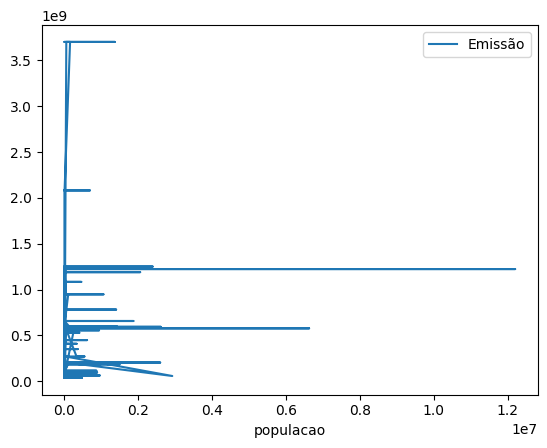

In [102]:
dados_agrupados.plot(x = 'populacao', y= 'Emissão')

O tipo do gráfico é scatter plot, portanto, passaremos kind igual à scatter entre aspas.

Por fim, passamos o tamanho da figura com o parâmetro figsize igual à (8,6). Também adicionamos ponto e vírgula para que nenhuma informação textual apareça em cima do gráfico.

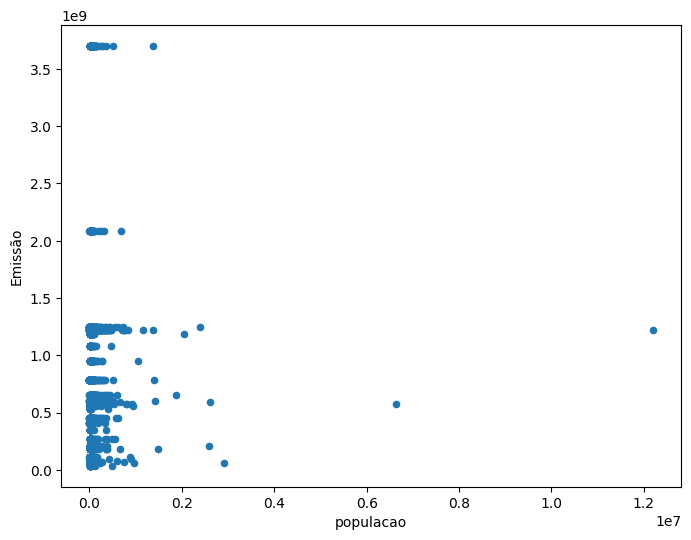

In [103]:
dados_agrupados.plot(x = 'populacao', y= 'Emissão', kind = 'scatter', figsize=(8,6));

O retorno é um gráfico de dispersão com a população no eixo x e a emissão no eixo y. Nele, temos diversos pontos que representam cada um dos registros da nossa tabela. A partir dele, queremos avaliar, com base no crescimento da população, se existe algum aumento na emissão.

Mas, não é possível identificar um padrão de aumento da população relacionado com a emissão. Pois, não conseguimos identificar quais são os estados que representam cada um dos pontos. Além disso, os valores de população e emissão estão em notação científica, o que dificulta a leitura.

Será que existe uma forma de melhoria dessa visualização? Discutiremos isso no próximo vídeo, onde também vamos prosseguir com a criação da métrica da emissão per capita.

Unimos os dados de emissão e população de cada estado para descobrir a emissão per capita de cada Estado. Entretanto, quando analisamos obtivemos um gráfico para verificarmos se há uma relação do tamanho da população daquele estado e a emissão, mas não conseguimos identificar quais os estados para cada ponto do gráfico.

Há um Estado com uma população (ponto na extremidade do lado direito do gráfico) e emissão (ponto na parte superior esquerda do gráfico) bastante altas, mas não conseguimos comparar com a emissão de outro estado que está mais acima. Porém, não sabemos quais são esses Estados (os pontos do gráfico).

Vamos aprimorar essa visualização para identificarmos qual estado corresponde a determinada emissão e população. Para isso, usamos uma biblioteca diferente da do Pandas chamada de biblioteca plotly. Esta nos permite gerar gráficos visualmente melhores e é específica para esse tipo de cenário.

Na próxima célula, vamos importar essa nova biblioteca. Escrevemos import plotly.express as px, estamos nomeando de px. Assim, todas as vezes que usarmos essa biblioteca a chamamos pelo nome px. Essa biblioteca já vem instalada no Google Colab, portanto, precisamos apenas executar o código de importação. Para rodar a célula, teclamos "Shift + Enter".

In [104]:
import plotly.express as px

Logo após, na célula seguinte, criamos um gráfico de dispersão mas usando essa nova biblioteca. Para isso, utilizamos o comando px.scatter() passando como primeiro parâmetro o dataframe (quais os dados com as informações que desejamos aplicar o plot). Escrevemos data_frame = dados_agrupados.

Como segundo parâmetro, colocamos o x (como fizemos no plot). O eixo horizontal (X) será referente a população e o eixo vertical (Y) a emissão. Na sequência, passamos outro parâmetro chamado de text que igualamos ao estado.

In [163]:
px.scatter(data_frame = dados_agrupados, x = 'populacao', y = 'Emissão', hover_name = 'Estado', color_discrete_sequence=['gray'],  size_max=60, width=1500,
           height=900)

Assim não exibimos somente o ponto do gráfico, e sim com o nome do Estado naquele determinado ponto. Com isso, vamos conseguir identificar qual o nome do Estado para cada informação. Também, não desejamos que seja exibido um ponto, e, sim, somente o nome.

Como o ponto é colocado por padrão no gráfico, para removê-lo podemos colocar no final da célula o parâmetro opacity = 0. Este serve para deixarmos o ponto invisível.

In [164]:
px.scatter(data_frame = dados_agrupados, x = 'populacao', y = 'Emissão', text = 'Estado', opacity = 0, size_max=100, width=1500, height=900)

Executando a célula, obtemos um gráfico com uma visualização mais interessante. No eixo vertical (Y) temos a emissão, e o eixo horizontal (X) temos a população, e ao invés dos pontos, temos os nomes dos Estados agora.

O Pará, por exemplo, ao colocarmos o cursor do mouse sobre ele (parte superior mais à esquerda do gráfico) temos que a população é de 8.442962M, a emissão é de 3.701684B e o Estado é o PA (Pará). Ou seja, possui uma emissão maior que os outros Estados.

Já São Paulo, temos que a população é de 46.02494M e a emissão 1.223309B. Isto é, São Paulo é o Estado com a maior população (lado direito do gráfico).

Conseguimos identificar, então, cada Estado, o quanto ele emite e qual a sua população.

Emissão per capita
Agora vamos fazer a emissão per capita de cada Estado e acrescentar essa informação no gráfico. Para tal, em uma nova célula, vamos fazer a divisão da emissão de cada Estado pela população para obtermos o resultado da emissão per capita.

Escrevemos, então, dados_agrupados = dados_agrupados e na sequência criamos uma nova coluna com base em duas colunas. Para isso, usamos o método assign() passando que desejamos criar uma coluna chamada de emissao_per_capita. Esta informação é com base na coluna de população e emissão, logo, dividimos a emissão pela população.

Colocamos um sinal de igual e escrevemos dados_agrupados[''] passando, primeiro, a emissão e depois a população. Logo após o fechamento dos colchetes, incluímos uma barra / e depois escrevemos dados_agrupados['populacao'].

Ao final da criação dessa nova coluna, vamos ordenar os dados da tabela com base na emissão per capita. Colocamos os valores de emissão per capita maiores no início da tabela, e os valores de emissão per capita menores colocamos ao final da tabela.

Para tal, usamos o .sort_values('') passando a coluna emissao_per_capita. Como desejamos do maior valor para o menor, usamos o parâmetro ascending = False. Na mesma célula, escrevemos dados_agrupados para visualizar o resultado desse código.

In [112]:
dados_agrupados = dados_agrupados.assign(emissao_per_capita = dados_agrupados['Emissão']/dados_agrupados['populacao']).sort_values('emissao_per_capita', ascending = False)
dados_agrupados

,Estado,Emissão,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,POPULAÇÃO,populacao_sem_parenteses,populacao,emissao_per_capita
2287,MT,2.081610e+09,MT,51,1209,Araguainha,998,998,998,2.085782e+06
2127,MG,1.250651e+09,MG,31,66600,Serra da Saudade,836,836,836,1.495994e+06
4867,SP,1.223309e+09,SP,35,7209,Borá,877,877,877,1.394879e+06
1516,MG,1.250651e+09,MG,31,15607,Cedro do Abaeté,1072,1072,1072,1.166652e+06
2400,MT,2.081610e+09,MT,51,7883,Serra Nova Dourada,1792,1792,1792,1.161613e+06
...,...,...,...,...,...,...,...,...,...,...
3660,RJ,5.767137e+08,RJ,33,4557,Rio de Janeiro,6625849,6625849,6625849,8.703998e+01
677,CE,2.034731e+08,CE,23,4400,Fortaleza,2596157,2596157,2596157,7.837474e+01
194,AP,3.568410e+07,AP,16,303,Macapá,478448,478448,478448,7.458303e+01
68,AL,6.261279e+07,AL,27,4302,Maceió,960667,960667,960667,6.517637e+01


Obtivemos a emissão per capita de cada Estado. Mas para melhorar, vamos criar uma visualização dessa informação com a biblioteca plotly usando um gráfico de barras.

Na célula seguinte, escrevemos px.bar() sendo o gráfico de barras da biblioteca plotly, passando data_frame = dados_agrupados. Acrescentamos uma vírgula, e na sequência colocamos que o eixo X (nome das colunas) será o Estado. Nesse caso, podemos passar tanto o Estado quanto o UF, passamos o Estado: x = 'Estado'. Como altura (eixo Y) da barra, passamos a emissão per capita

In [138]:
px.bar(data_frame = dados_agrupados, x = 'Estado', y = 'emissao_per_capita', color_discrete_sequence=['green'])

Como retorno, obtemos um gráfico de barras com as informações que já estamos acostumados. No eixo Y (vertical) temos a emissão per capita e no eixo X (horizontal) temos os Estados. Passando o mouse por cima das barras, por exemplo, a primeira da esquerda para a direita, que representa o Estado de Roraima (RR), contém emissão per capita de 832.0777.

Agora, vamos copiar o código da célula onde fizemos o gráfico de scatter() e alterá-lo para colocar as informações dos pontos do gráfico para bolhas. Logo, vamos aumentar o tamanho do ponto com base na emissão per capita.

Será um gráfico que irá identificar a população, a emissão e a emissão per capita de cada Estado.

Após colarmos o código em uma nova célula, ao invés de usarmos uma opacity igual a 0, colocamos o tamanho (size) igual a emissao_per_capita. Dessa forma, o tamanho do ponto do gráfico será maior conforme a emissão per capita daquele Estado.

In [135]:
fig = px.scatter(data_frame = dados_agrupados, x = 'populacao', y = 'Emissão', hover_name = 'Estado', size = 'emissao_per_capita', color = 'emissao_per_capita',
                 color_continuous_scale='Viridis', size_max=60, width=1200, height=800)
fig.update_layout(coloraxis_showscale=False)
fig.show()

Executando a célula, obtemos um gráfico de dispersão com os nomes dos Estados ao invés de simplesmente termos um ponto, mas desta vez os pontos estão de tamanhos diferentes (maiores ou menores) de acordo com a emissão per capita do Estado que ele está representando.

No Pará, por exemplo, é o Estado que contém a maior emissão, mas com base em sua população, ele não contém o círculo maior que os outros Estados. O Estado que aparentemente possui a maior emissão per capita é o de Roraima, que analisando podemos visualizar que o círculo está maior mesmo.

O Estado de Roraima possui uma população de 634.805K (um pouco baixa), uma emissão de 528.2071M e uma emissão per capita de 832.077.

Conseguimos identificar todas as informações solicitadas pela equipe de supervisão. Isso será útil para o órgão ambiental identificar se os Estados estão dentro das diretrizes de emissão de gases estufa.